In [ ]:
# import numpy as np
# import torch

# def lidar_to_bev(points, bev_spec):
#     """
#     points: Nx4 array  [x, y, z, intensity]
#     bev_spec: BEVSpec defining x_min/x_max/y_min/y_max/cell sizes
#     """
#     x = points[:, 0]
#     y = points[:, 1]
#     z = points[:, 2]
#     i = points[:, 3]

#     # Filter points inside BEV area
#     mask = (x >= bev_spec.x_min) & (x < bev_spec.x_max) & \
#            (y >= bev_spec.y_min) & (y < bev_spec.y_max)
#     x = x[mask]; y = y[mask]; z = z[mask]; i = i[mask]

#     # Convert to BEV grid coords
#     H = bev_spec.H
#     W = bev_spec.W
#     ix = ((x - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
#     iy = ((y - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)

#     # Channels
#     bev_occ   = np.zeros((H, W), dtype=np.float32)
#     bev_height = np.zeros((H, W), dtype=np.float32)
#     bev_int   = np.zeros((H, W), dtype=np.float32)
#     bev_count = np.zeros((H, W), dtype=np.float32)

#     # Fill BEV
#     for px, py, pz, pi in zip(ix, iy, z, i):
#         bev_occ[px, py] = 1
#         bev_height[px, py] = max(bev_height[px, py], pz)
#         bev_int[px, py] += pi
#         bev_count[px, py] += 1

#     # Normalize intensity by count
#     bev_mean_int = bev_int / (bev_count + 1e-6)

#     # Stack channels
#     bev = np.stack([bev_occ, bev_height, bev_mean_int], axis=0)

#     return torch.tensor(bev, dtype=torch.float32)


In [ ]:
# Load raw .pcd.bin
import numpy as np

lidar_bin = "/home/draiman/Desktop/datasets/nuscenes/samples/LIDAR_TOP/n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"

points = np.fromfile(lidar_bin, dtype=np.float32).reshape(-1, 5)  # nuscenes = x,y,z,intensity,ring
points = points[:, :4]  # keep x,y,z,i
print(points.shape)
points[:5]


(34720, 4)


array([[-3.1790197 , -0.14813471, -1.8944526 ,  4.        ],
       [-3.3147244 , -0.14445566, -1.8713316 , 16.        ],
       [-3.4914439 , -0.14043893, -1.8650968 , 18.        ],
       [-3.694841  , -0.1352142 , -1.8635675 , 14.        ],
       [-3.924954  , -0.12998559, -1.866178  , 22.        ]],
      dtype=float32)

In [ ]:
# Define BEVSpec
class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min; self.x_max = x_max; self.cell_x = cell_x
        self.y_min = y_min; self.y_max = y_max; self.cell_y = cell_y
    
    @property
    def H(self): return int(np.ceil((self.x_max - self.x_min) / self.cell_x))
    @property
    def W(self): return int(np.ceil((self.y_max - self.y_min) / self.cell_y))
# front half x_min=0.0,, to see full 360deg, use x_min=-50.0 
bev_spec = BEVSpec(
    x_min=0.0,  x_max=50.0, cell_x=0.4,
    y_min=-25.0, y_max=25.0, cell_y=0.25
)
bev_spec.H, bev_spec.W


(125, 200)

In [ ]:
# Raw LiDAR → BEV

import torch

def lidar_to_bev(points, bev_spec):
    x, y, z, i = points.T

    mask = (x >= bev_spec.x_min) & (x < bev_spec.x_max) & \
           (y >= bev_spec.y_min) & (y < bev_spec.y_max)
    x, y, z, i = x[mask], y[mask], z[mask], i[mask]

    ix = ((x - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
    iy = ((y - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)

    H, W = bev_spec.H, bev_spec.W
    bev_occ   = np.zeros((H, W), dtype=np.float32)
    bev_height = np.zeros((H, W), dtype=np.float32)
    bev_int   = np.zeros((H, W), dtype=np.float32)
    bev_count = np.zeros((H, W), dtype=np.float32)

    for px, py, pz, pi in zip(ix, iy, z, i):
        bev_occ[px, py] = 1
        bev_height[px, py] = max(bev_height[px, py], pz)
        bev_int[px, py] += pi
        bev_count[px, py] += 1

    bev_mean_int = bev_int / (bev_count + 1e-6)

    bev = np.stack([bev_occ, bev_height, bev_mean_int], axis=0)
    return bev

bev = lidar_to_bev(points, bev_spec)
bev.shape


(3, 125, 200)

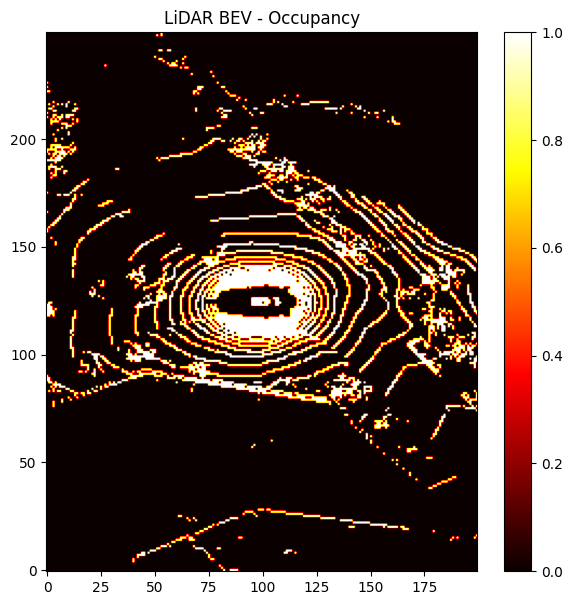

In [ ]:
# Visualize occupancy
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.imshow(bev[0], cmap="hot", origin="lower")
plt.title("LiDAR BEV - Occupancy")
plt.colorbar()
plt.show()


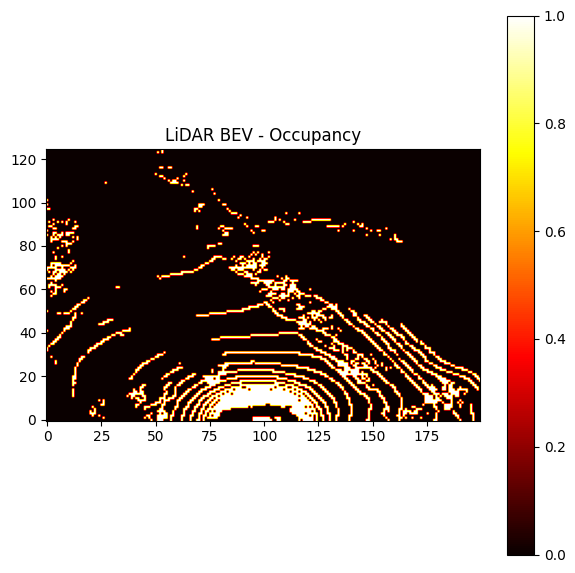

In [22]:
# Visualize occupancy
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.imshow(bev[0], cmap="hot", origin="lower")
plt.title("LiDAR BEV - Occupancy")
plt.colorbar()
plt.show()

Original: (36720, 4)
Synthetic cluster: (2000, 4)


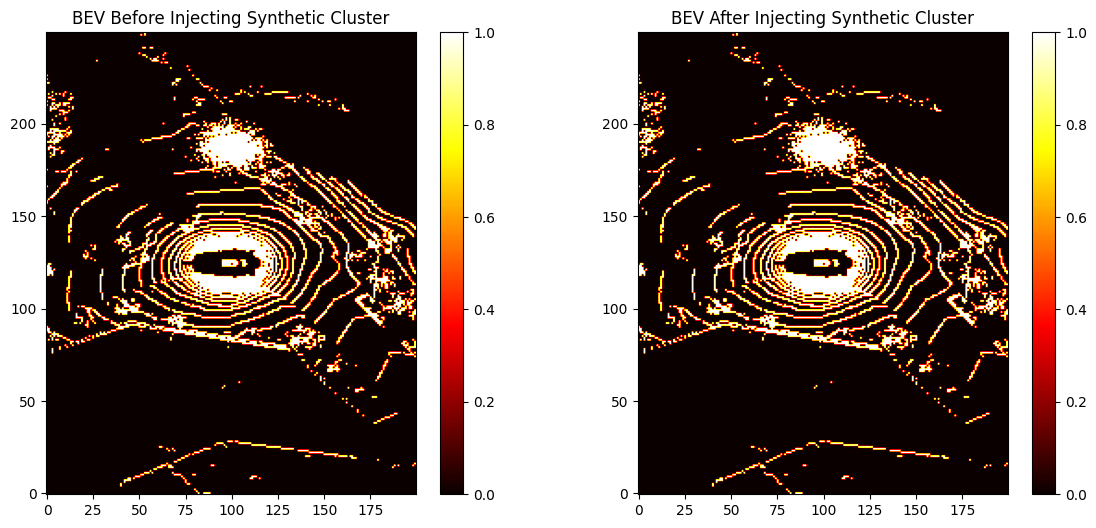

In [ ]:
# ---------------------------------------------------------
# 1. Load original LiDAR (same as before)
# ---------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

lidar_bin = "/home/draiman/Desktop/datasets/nuscenes/samples/LIDAR_TOP/n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"
# lidar_bin = "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/dataset/n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"

pts = np.fromfile(lidar_bin, dtype=np.float32).reshape(-1, 5)[:, :4]  # x,y,z,intensity
print("Original:", pts.shape)


# ---------------------------------------------------------
# 2. Define BEV spec (front 50m × 50m)
# ---------------------------------------------------------
class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min; self.x_max = x_max; self.cell_x = cell_x
        self.y_min = y_min; self.y_max = y_max; self.cell_y = cell_y
    
    @property
    def H(self): return int(np.ceil((self.x_max - self.x_min) / self.cell_x))
    @property
    def W(self): return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(
    x_min=-50.0,  x_max=50.0, cell_x=0.4,
    y_min=-25.0, y_max=25.0, cell_y=0.25
)


# ---------------------------------------------------------
# 3. Build a function converting point cloud to BEV
# ---------------------------------------------------------
def lidar_to_bev(points, bev_spec):
    x, y, z, i = points.T

    mask = (x >= bev_spec.x_min) & (x < bev_spec.x_max) & \
           (y >= bev_spec.y_min) & (y < bev_spec.y_max)
    x, y, z, i = x[mask], y[mask], z[mask], i[mask]

    ix = ((x - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
    iy = ((y - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)

    H, W = bev_spec.H, bev_spec.W

    bev_occ    = np.zeros((H, W), dtype=np.float32)

    for px, py in zip(ix, iy):
        bev_occ[px, py] = 1.0

    return bev_occ


# ---------------------------------------------------------
# 4. Inject synthetic dense cluster at known position
# ---------------------------------------------------------
# Choose physical location (meters)
cluster_x = 25.0   # forward
cluster_y =  0.0   # right
cluster_z =  0.5

# Generate ~500 dense points in a small sphere
N = 2000
rng = np.random.default_rng(0)
sphere = rng.normal(scale=2, size=(N, 3))  # small 25cm cluster
sphere[:, 2] *= 0.1                            # flatten vertically

cluster_pts = np.zeros((N, 4))
cluster_pts[:, 0] = cluster_x + sphere[:, 0]
cluster_pts[:, 1] = cluster_y + sphere[:, 1]
cluster_pts[:, 2] = cluster_z + sphere[:, 2]
cluster_pts[:, 3] = 1.0  # intensity

print("Synthetic cluster:", cluster_pts.shape)

# Merge cluster with original cloud
pts_with_cluster = np.vstack([pts, cluster_pts])


# ---------------------------------------------------------
# 5. Convert to BEV maps (before + after)
# ---------------------------------------------------------
bev_before = lidar_to_bev(pts, bev_spec)
bev_after  = lidar_to_bev(pts_with_cluster, bev_spec)


# ---------------------------------------------------------
# 6. Plot: before vs after (geometric alignment test)
# ---------------------------------------------------------
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(bev_before, cmap="hot", origin="lower")
plt.title("BEV Before Injecting Synthetic Cluster")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(bev_after, cmap="hot", origin="lower")
plt.title("BEV After Injecting Synthetic Cluster")
plt.colorbar()

plt.show()


Original: (34720, 4)
Synthetic cluster: (50, 4)


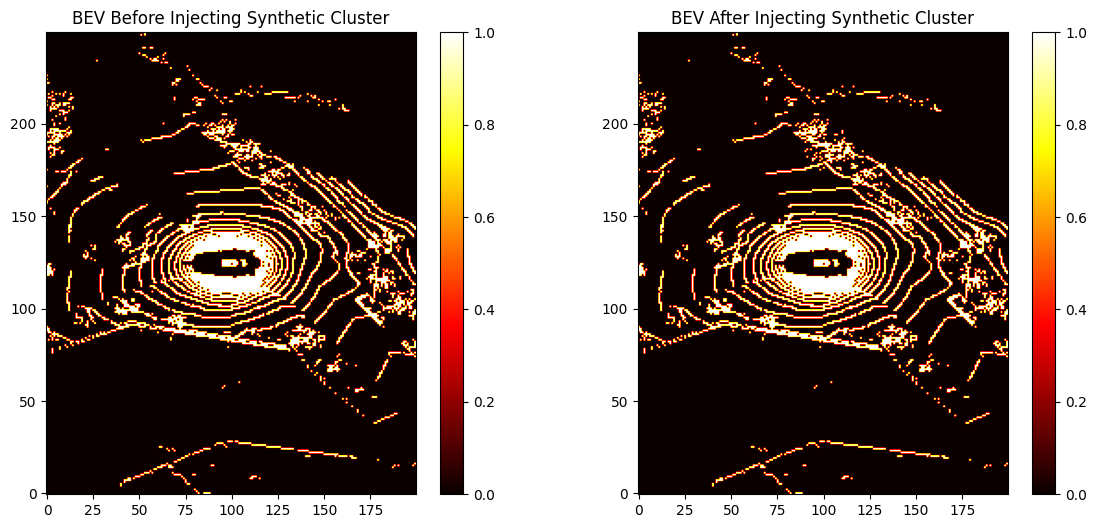

In [21]:
# ---------------------------------------------------------
# 1. Load original LiDAR (same as before)
# ---------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

lidar_bin = "/home/draiman/Desktop/datasets/nuscenes/samples/LIDAR_TOP/n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"

pts = np.fromfile(lidar_bin, dtype=np.float32).reshape(-1, 5)[:, :4]  # x,y,z,intensity
print("Original:", pts.shape)


# ---------------------------------------------------------
# 2. Define BEV spec (front 50m × 50m)
# ---------------------------------------------------------
class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min; self.x_max = x_max; self.cell_x = cell_x
        self.y_min = y_min; self.y_max = y_max; self.cell_y = cell_y
    
    @property
    def H(self): return int(np.ceil((self.x_max - self.x_min) / self.cell_x))
    @property
    def W(self): return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(
    x_min=-50.0,  x_max=50.0, cell_x=0.4,
    y_min=-25.0, y_max=25.0, cell_y=0.25
)


# ---------------------------------------------------------
# 3. Build a function converting point cloud to BEV
# ---------------------------------------------------------
def lidar_to_bev(points, bev_spec):
    x, y, z, i = points.T

    mask = (x >= bev_spec.x_min) & (x < bev_spec.x_max) & \
           (y >= bev_spec.y_min) & (y < bev_spec.y_max)
    x, y, z, i = x[mask], y[mask], z[mask], i[mask]

    ix = ((x - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
    iy = ((y - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)

    H, W = bev_spec.H, bev_spec.W

    bev_occ    = np.zeros((H, W), dtype=np.float32)

    for px, py in zip(ix, iy):
        bev_occ[px, py] = 1.0

    return bev_occ


# ---------------------------------------------------------
# 4. Inject synthetic dense cluster at known position
# ---------------------------------------------------------
# Choose physical location (meters)
cluster_x = 25.0   # forward
cluster_y =  0.0   # right
cluster_z =  0.5

# Generate ~500 dense points in a small sphere
N = 50
# N = 2000
rng = np.random.default_rng(0)
sphere = rng.normal(scale=2, size=(N, 3))  # small 25cm cluster
sphere[:, 2] *= 0.1                            # flatten vertically

cluster_pts = np.zeros((N, 4))
cluster_pts[:, 0] = cluster_x + sphere[:, 0]
cluster_pts[:, 1] = cluster_y + sphere[:, 1]
cluster_pts[:, 2] = cluster_z + sphere[:, 2]
cluster_pts[:, 3] = 1.0  # intensity

print("Synthetic cluster:", cluster_pts.shape)

# Merge cluster with original cloud
# pts_with_cluster = np.vstack([pts, cluster_pts])
pts_with_50pts_cluster = np.vstack([pts, cluster_pts])

# ---------------------------------------------------------
# 5. Convert to BEV maps (before + after)
# ---------------------------------------------------------
bev_before = lidar_to_bev(pts, bev_spec)
# bev_after  = lidar_to_bev(pts_with_cluster, bev_spec)
bev_after  = lidar_to_bev(pts_with_50pts_cluster, bev_spec)


# ---------------------------------------------------------
# 6. Plot: before vs after (geometric alignment test)
# ---------------------------------------------------------
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(bev_before, cmap="hot", origin="lower")
plt.title("BEV Before Injecting Synthetic Cluster")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(bev_after, cmap="hot", origin="lower")
plt.title("BEV After Injecting Synthetic Cluster")
plt.colorbar()

plt.show()


In [26]:
from pathlib import Path
# # ---------------------------------------------------------
# # Save the modified LiDAR with synthetic cluster
# # ---------------------------------------------------------

# save_path = "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/dataset/synthetic_n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"

# # pts_with_cluster: (N, 4) = x,y,z,intensity
# # NuScenes expects (N, 5) = x,y,z,intensity,ring
# ring = np.zeros((pts_with_cluster.shape[0], 1), dtype=np.float32)

# pts_5d = np.hstack([pts_with_cluster.astype(np.float32), ring])

# print("Saving:", pts_5d.shape, "→", save_path)
# pts_5d.tofile(save_path)

# print("✅ Saved synthetic LiDAR file with cluster.")




# ---------------------------------------------------------
# Save the modified LiDAR with synthetic cluster
# ---------------------------------------------------------

OUT_DIR   = Path("/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/dataset")
OUT_DIR.mkdir(parents=True, exist_ok=True)
save_path = OUT_DIR / "synthetic_50pts_n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"


# pts_with_cluster: (N, 4) = x,y,z,intensity
# NuScenes expects (N, 5) = x,y,z,intensity,ring
ring = np.zeros((pts_with_50pts_cluster.shape[0], 1), dtype=np.float32)

pts_5d = np.hstack([pts_with_50pts_cluster.astype(np.float32), ring])

print("Saving:", pts_5d.shape, "→", save_path)
pts_5d.tofile(save_path)

print("✅ Saved synthetic LiDAR file with cluster.")


Saving: (34770, 5) → /home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/dataset/synthetic_50pts_n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin
✅ Saved synthetic LiDAR file with cluster.


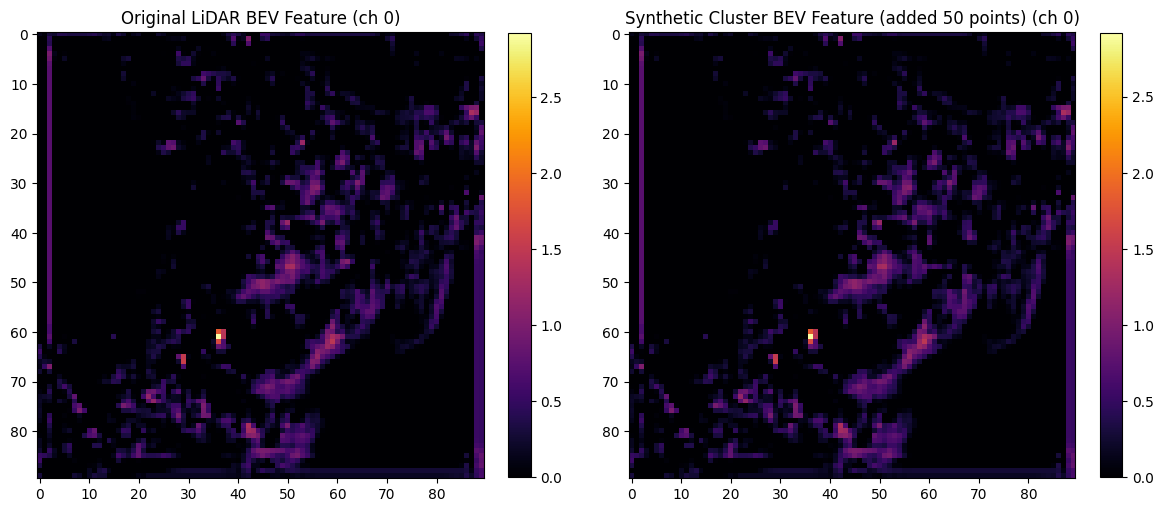

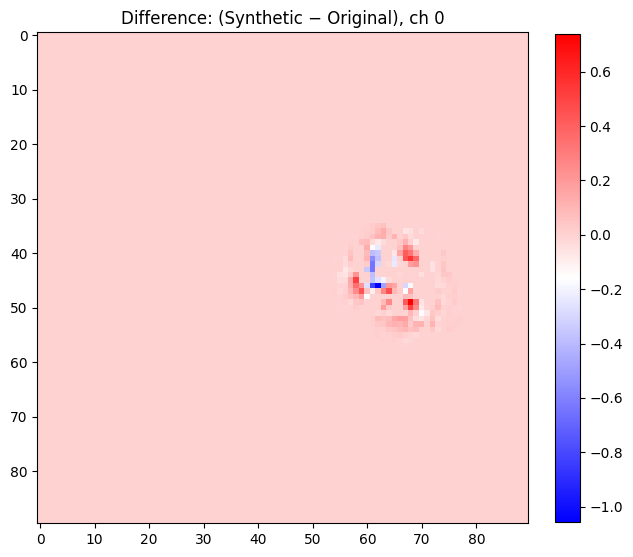

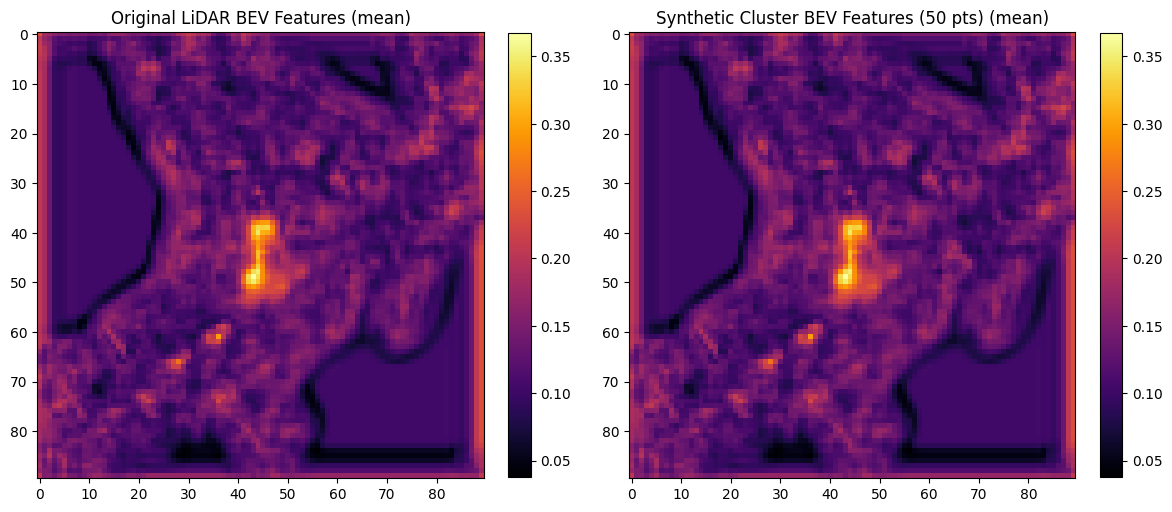

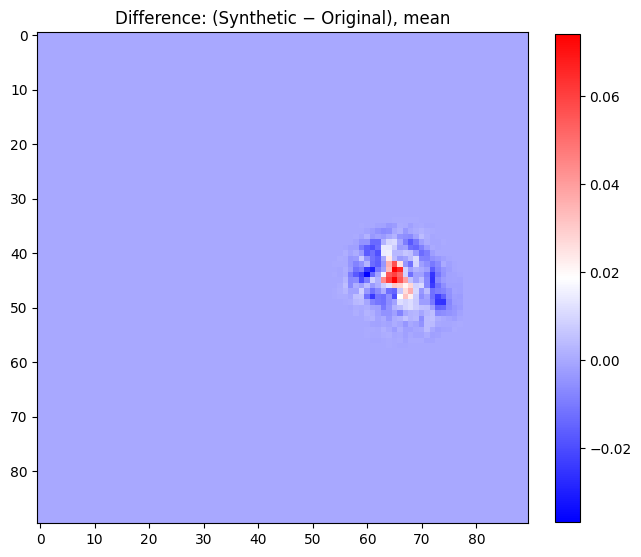

In [44]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load both features
# ============================
feat_orig  = torch.load("/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features/file_1.pt",
                        map_location="cpu")["feat"].numpy()[0]   # [256, H, W]

feat_synth = torch.load("/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features/file_synth_50pts.pt",
                        map_location="cpu")["feat"].numpy()[0]   # [256, H, W]

# pick channel 0 or any other (CenterPoint has 256 channels)
ch = 0
orig_ch  = feat_orig[ch]
synth_ch = feat_synth[ch]

# ============================
# Plot side-by-side
# ============================
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(orig_ch, cmap="inferno")
plt.title("Original LiDAR BEV Feature (ch 0)")
plt.colorbar(fraction=0.045)

plt.subplot(1, 2, 2)
plt.imshow(synth_ch, cmap="inferno")
plt.title("Synthetic Cluster BEV Feature (added 50 points) (ch 0)")
plt.colorbar(fraction=0.045)

plt.show()

plt.figure(figsize=(7,7))
plt.imshow(synth_ch - orig_ch, cmap="bwr")
plt.title("Difference: (Synthetic − Original), ch 0")
plt.colorbar(fraction=0.045)
plt.show()


# pick channel 0 or any other (CenterPoint has 256 channels)

# Compute mean across channels → shape [H, W]
orig_mean  = feat_orig.mean(axis=0)
synth_mean = feat_synth.mean(axis=0)

# ============================
# Plot side-by-side
# ============================
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(orig_mean, cmap="inferno")
plt.title("Original LiDAR BEV Features (mean)")
plt.colorbar(fraction=0.045)

plt.subplot(1, 2, 2)
plt.imshow(synth_mean, cmap="inferno")
plt.title("Synthetic Cluster BEV Features (50 pts) (mean)")
plt.colorbar(fraction=0.045)

plt.show()

plt.figure(figsize=(7,7))
plt.imshow(synth_mean - orig_mean, cmap="bwr")
plt.title("Difference: (Synthetic − Original), mean")
plt.colorbar(fraction=0.045)
plt.show()



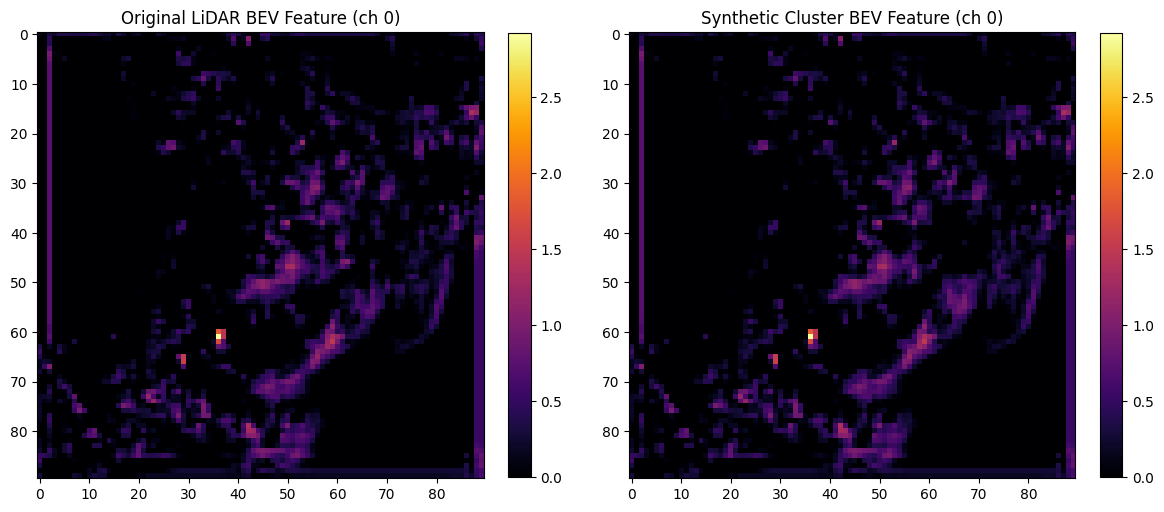

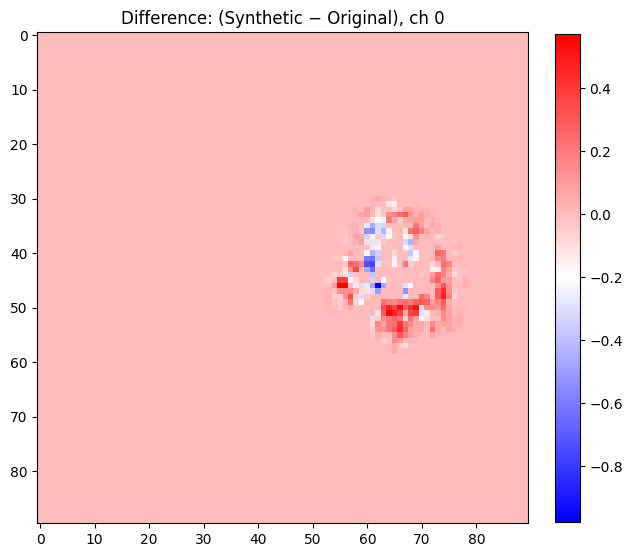

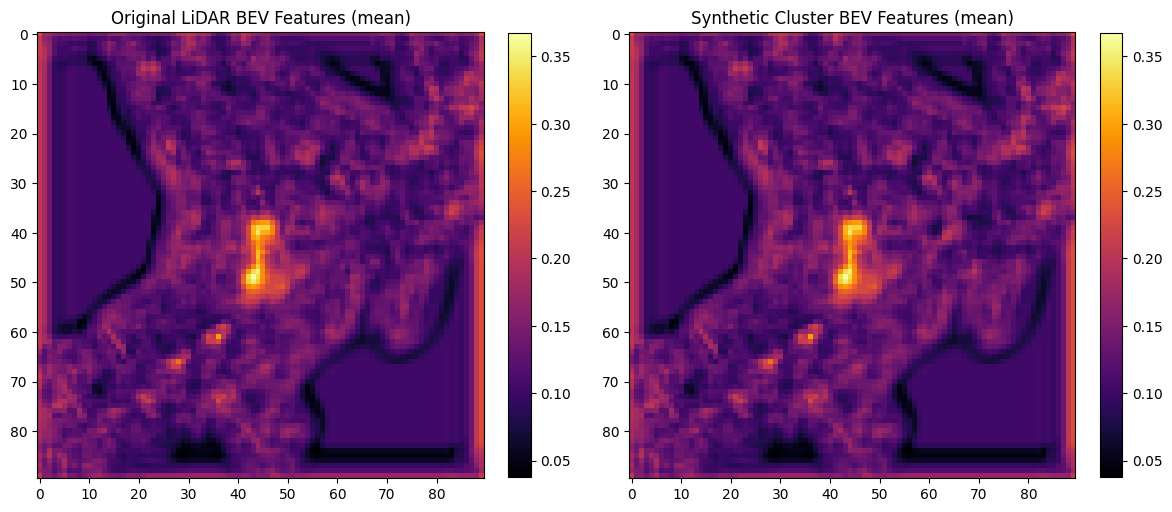

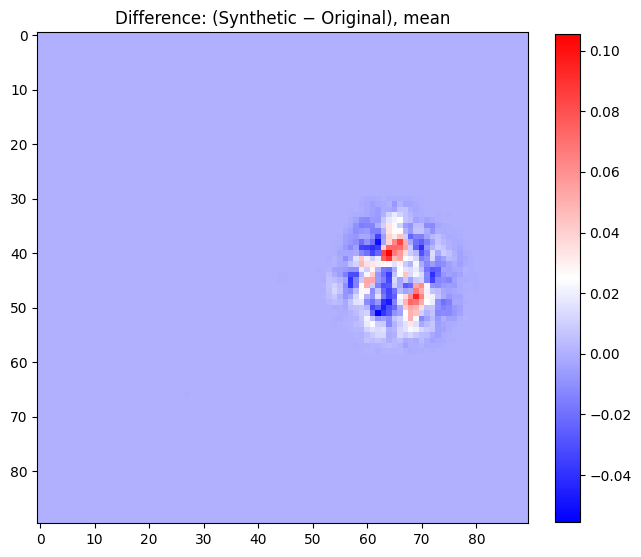

In [45]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load both features
# ============================
feat_orig  = torch.load("/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features/file_1.pt",
                        map_location="cpu")["feat"].numpy()[0]   # [256, H, W]

feat_synth = torch.load("/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features/file_synth.pt",
                        map_location="cpu")["feat"].numpy()[0]   # [256, H, W]

# pick channel 0 or any other (CenterPoint has 256 channels)
ch = 0
orig_ch  = feat_orig[ch]
synth_ch = feat_synth[ch]

# ============================
# Plot side-by-side
# ============================
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(orig_ch, cmap="inferno")
plt.title("Original LiDAR BEV Feature (ch 0)")
plt.colorbar(fraction=0.045)

plt.subplot(1, 2, 2)
plt.imshow(synth_ch, cmap="inferno")
plt.title("Synthetic Cluster BEV Feature (ch 0)")
plt.colorbar(fraction=0.045)

plt.show()

plt.figure(figsize=(7,7))
plt.imshow(synth_ch - orig_ch, cmap="bwr")
plt.title("Difference: (Synthetic − Original), ch 0")
plt.colorbar(fraction=0.045)
plt.show()



# pick channel 0 or any other (CenterPoint has 256 channels)

# Compute mean across channels → shape [H, W]
orig_mean  = feat_orig.mean(axis=0)
synth_mean = feat_synth.mean(axis=0)

# ============================
# Plot side-by-side
# ============================
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(orig_mean, cmap="inferno")
plt.title("Original LiDAR BEV Features (mean)")
plt.colorbar(fraction=0.045)

plt.subplot(1, 2, 2)
plt.imshow(synth_mean, cmap="inferno")
plt.title("Synthetic Cluster BEV Features (mean)")
plt.colorbar(fraction=0.045)

plt.show()

plt.figure(figsize=(7,7))
plt.imshow(synth_mean - orig_mean, cmap="bwr")
plt.title("Difference: (Synthetic − Original), mean")
plt.colorbar(fraction=0.045)
plt.show()




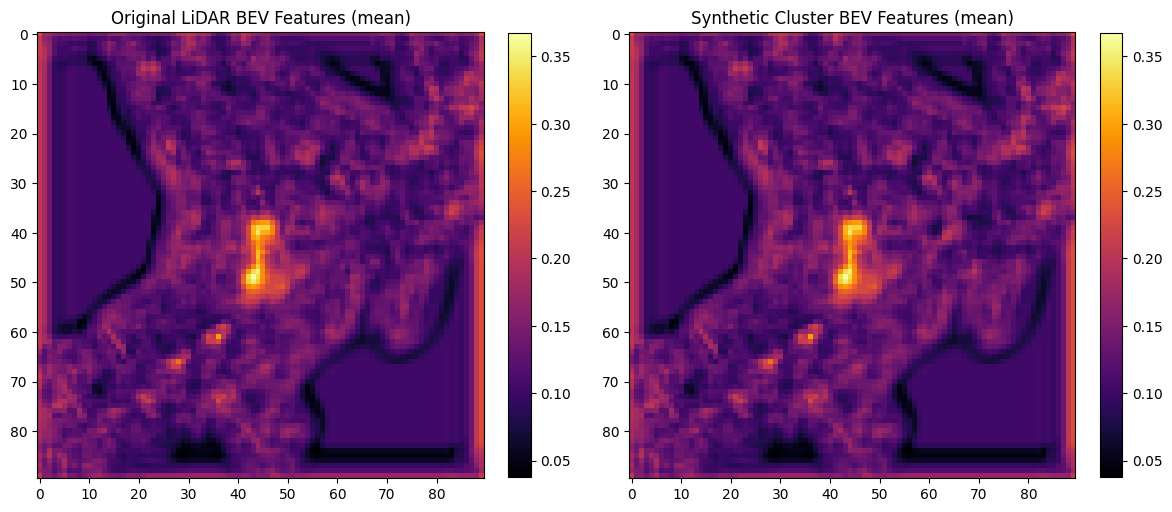

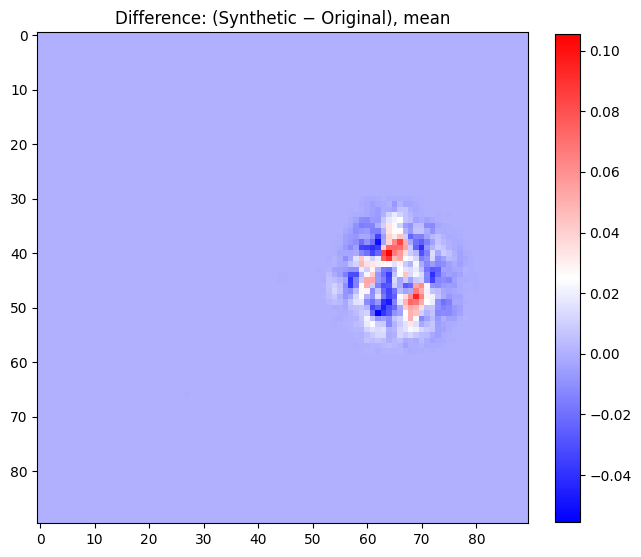

visualize centerpoint earlier layers

In [37]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load both features
# ============================
feat_orig  = torch.load("/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/benign_early_layers.pt",
                        map_location="cpu")

feat_synth = torch.load("/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/synthetic_early_layers.pt",
                        map_location="cpu")


feat_synth_2000pts = torch.load("/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/synthetic_early_layers.pt",
                        map_location="cpu")


feat_synth_50pts = torch.load("/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/synthetic_50pts_early_layers.pt",
                        map_location="cpu")


In [ ]:
print(feat_orig.keys())
print(feat_orig['voxel_feats'].numpy().shape)
print(feat_orig['spatial'].numpy().shape)
print(feat_orig['bev_c1'].numpy().shape)
print(feat_orig['bev_c2'].numpy().shape)


feat_orig_voxel_feats = feat_orig['voxel_feats'].numpy()
feat_orig_spatial = feat_orig['spatial'].numpy()
feat_orig_bev_c1 = feat_orig['bev_c1'].numpy()
feat_orig_bev_c2 = feat_orig['bev_c2'].numpy()


feat_synth_voxel_feats = feat_synth['voxel_feats'].numpy()
feat_synth_spatial = feat_synth['spatial'].numpy()
feat_synth_bev_c1 = feat_synth['bev_c1'].numpy()
feat_synth_bev_c2 = feat_synth['bev_c2'].numpy()






dict_keys(['voxel_feats', 'spatial', 'bev_c1', 'bev_c2'])
(16725, 5)
(1, 256, 180, 180)
(1, 128, 180, 180)
(1, 256, 90, 90)


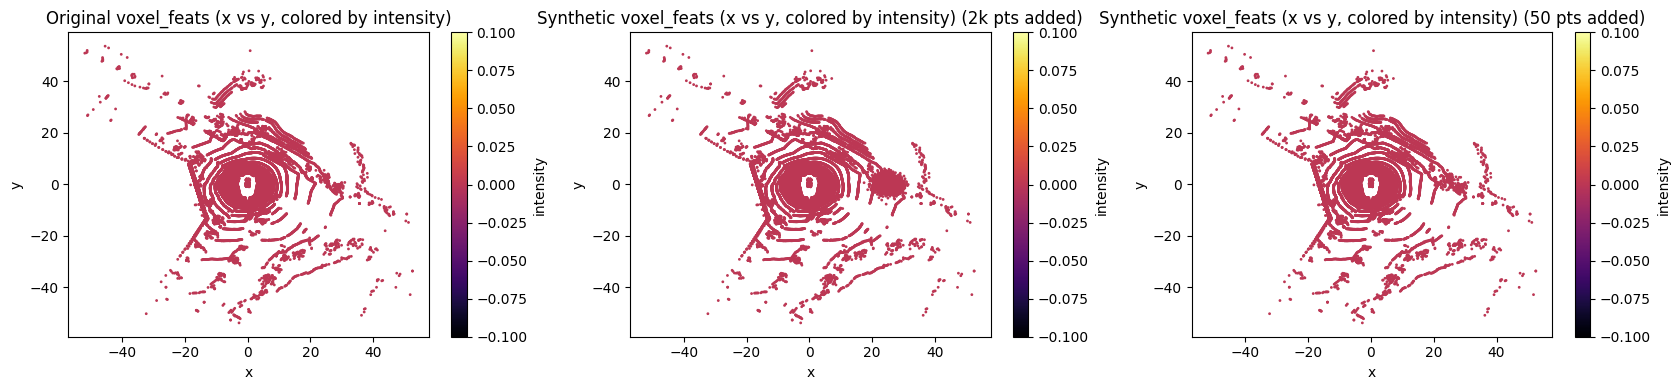

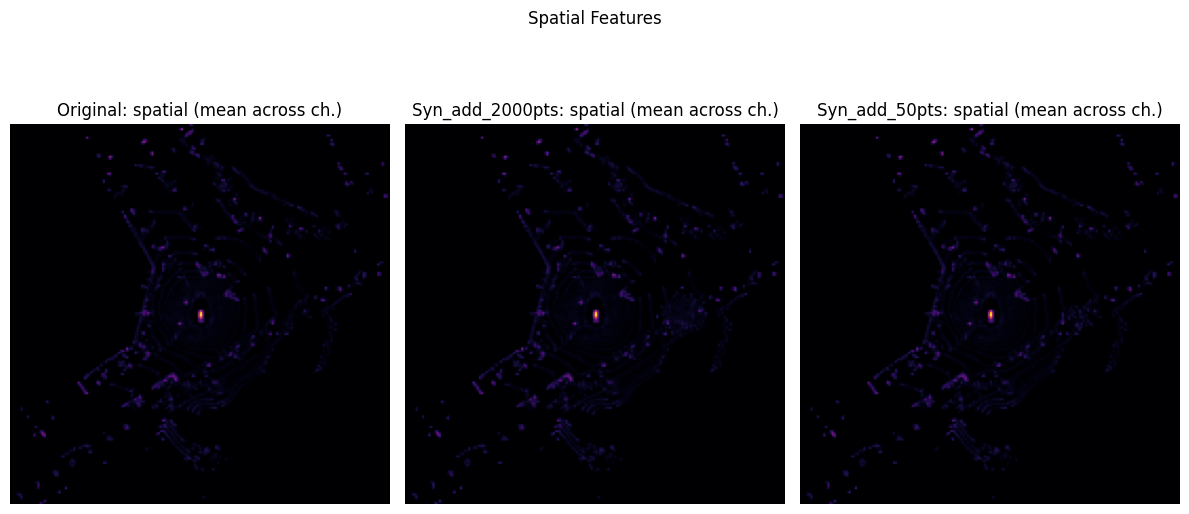

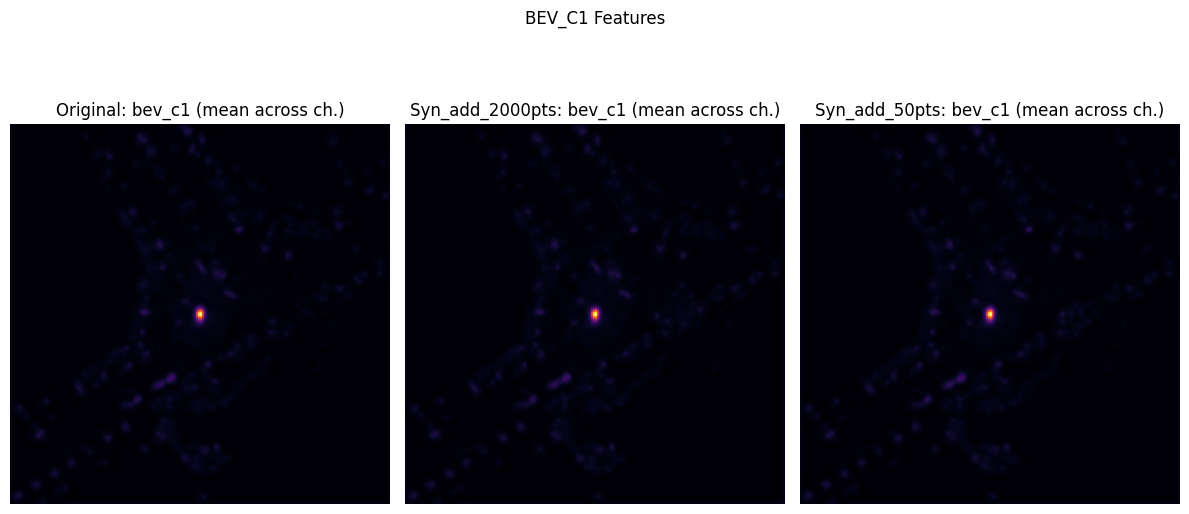

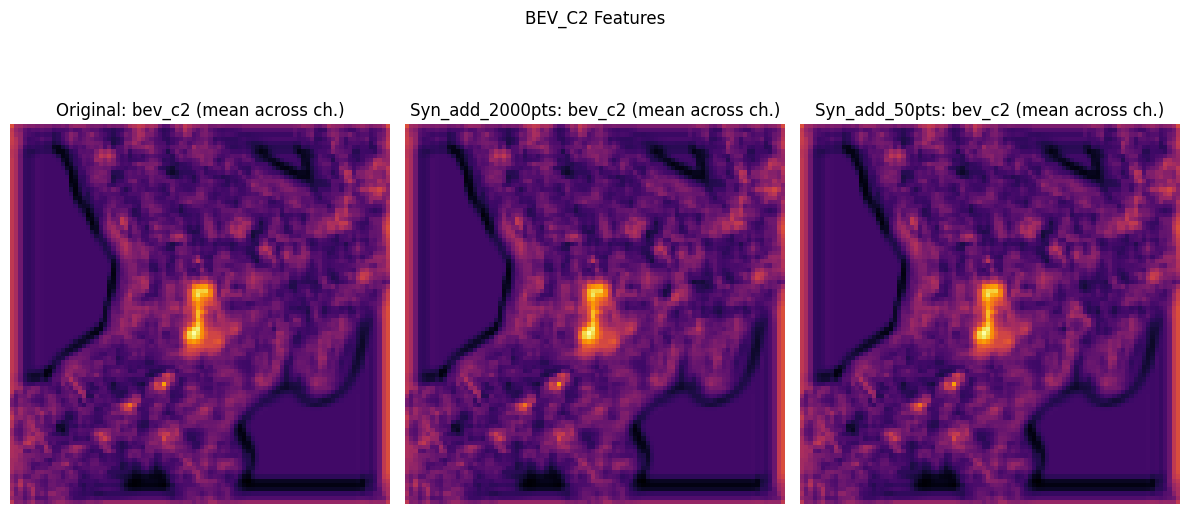

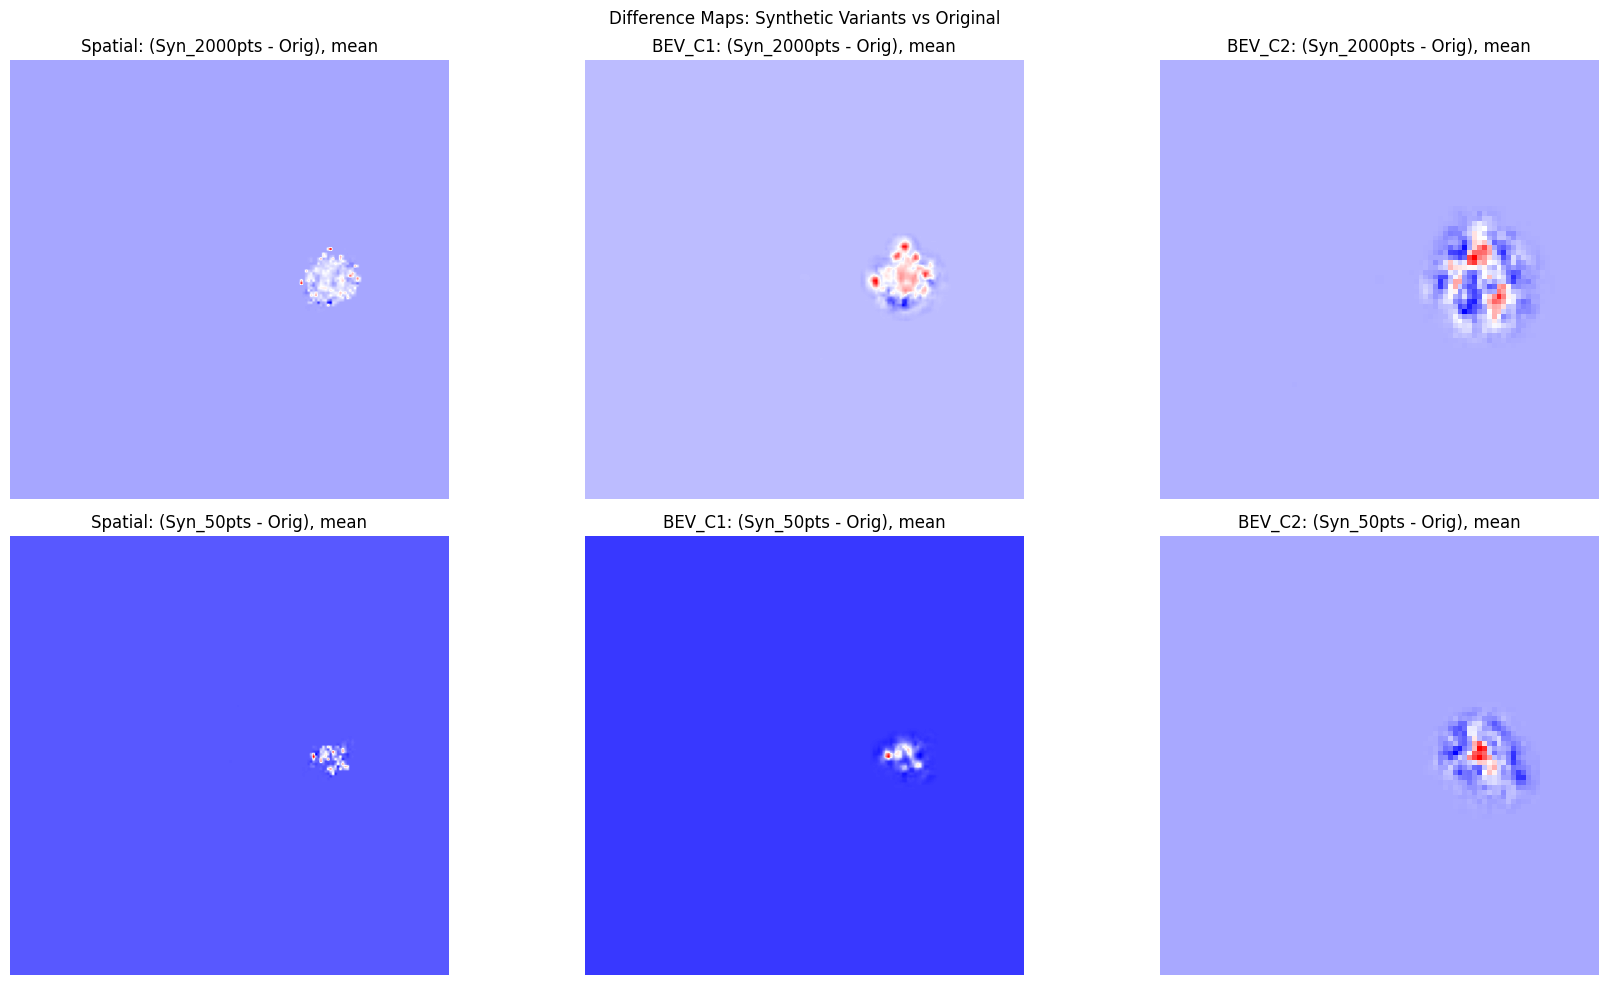

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# --- Unpack features ---
# Example: feat_orig and feat_synth are loaded dicts from torch.load()
# Keys: 'voxel_feats', 'spatial', 'bev_c1', 'bev_c2'
# 1. Voxel features (shape: [N_voxels, 5])
voxel_feats_orig  = feat_orig['voxel_feats'].numpy()
voxel_feats_synth_2000pts = feat_synth_2000pts['voxel_feats'].numpy()
voxel_feats_synth_50pts = feat_synth_50pts['voxel_feats'].numpy()

# 2. Spatial features (shape: [1, 256, 180, 180])
spatial_orig  = feat_orig['spatial'].numpy()[0]     # (256, 180, 180)
spatial_synth = feat_synth_2000pts['spatial'].numpy()[0]
spatial_synth_50pts = feat_synth_50pts['spatial'].numpy()[0]

# 3. BEV_C1 features (shape: [1, 128, 180, 180])
bev_c1_orig  = feat_orig['bev_c1'].numpy()[0]       # (128, 180, 180)
bev_c1_synth = feat_synth_2000pts['bev_c1'].numpy()[0]
bev_c1_synth_50pts = feat_synth_50pts['bev_c1'].numpy()[0]

# 4. BEV_C2 features (shape: [1, 256, 90, 90])
bev_c2_orig  = feat_orig['bev_c2'].numpy()[0]       # (256, 90, 90)
bev_c2_synth = feat_synth_2000pts['bev_c2'].numpy()[0]
bev_c2_synth_50pts = feat_synth_50pts['bev_c2'].numpy()[0]

# --- Plot Voxel Feats (scatter, first 2 dims as x/y, color by intensity) ---
plt.figure(figsize=(17, 4))

plt.subplot(1, 3, 1)
plt.scatter(voxel_feats_orig[:, 0], voxel_feats_orig[:, 1], c=voxel_feats_orig[:, 4], cmap='inferno', s=1)
plt.title('Original voxel_feats (x vs y, colored by intensity)')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='intensity')

plt.subplot(1, 3, 2)
plt.scatter(voxel_feats_synth_2000pts[:, 0], voxel_feats_synth_2000pts[:, 1], c=voxel_feats_synth_2000pts[:, 4], cmap='inferno', s=1)
plt.title('Synthetic voxel_feats (x vs y, colored by intensity) (2k pts added)')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='intensity')



plt.subplot(1, 3, 3)
plt.scatter(voxel_feats_synth_50pts[:, 0], voxel_feats_synth_50pts[:, 1], c=voxel_feats_synth_50pts[:, 4], cmap='inferno', s=1)
plt.title('Synthetic voxel_feats (x vs y, colored by intensity) (50 pts added)')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='intensity')
plt.tight_layout()
plt.show()


# --- Helper: Plot mean across channels ---
def plot_mean_feats(ax, data, title, cmap="inferno"):
    ax.imshow(data.mean(axis=0), cmap=cmap)
    ax.set_title(title)
    ax.axis('off')

# --- 2. Plot Spatial features [mean across channels] ---
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
plot_mean_feats(axs[0], spatial_orig,  "Original: spatial (mean across ch.)")
plot_mean_feats(axs[1], spatial_synth, "Syn_add_2000pts: spatial (mean across ch.)")
plot_mean_feats(axs[2], spatial_synth_50pts, "Syn_add_50pts: spatial (mean across ch.)")
plt.suptitle("Spatial Features")
plt.tight_layout()
plt.show()

# --- 3. Plot BEV_C1 features [mean across channels] ---
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
plot_mean_feats(axs[0], bev_c1_orig,  "Original: bev_c1 (mean across ch.)")
plot_mean_feats(axs[1], bev_c1_synth, "Syn_add_2000pts: bev_c1 (mean across ch.)")
plot_mean_feats(axs[2], bev_c1_synth_50pts, "Syn_add_50pts: bev_c1 (mean across ch.)")
plt.suptitle("BEV_C1 Features")
plt.tight_layout()
plt.show()

# --- 4. Plot BEV_C2 features [mean across channels] ---
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
plot_mean_feats(axs[0], bev_c2_orig,  "Original: bev_c2 (mean across ch.)")
plot_mean_feats(axs[1], bev_c2_synth, "Syn_add_2000pts: bev_c2 (mean across ch.)")
plot_mean_feats(axs[2], bev_c2_synth_50pts, "Syn_add_50pts: bev_c2 (mean across ch.)")
plt.suptitle("BEV_C2 Features")
plt.tight_layout()
plt.show()


# --- 5. Plot the difference (synthetic - original) for each feature and both synth variants ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# First row: diff for synth_2000pts - orig
diff_spatial_2000 = spatial_synth.mean(axis=0) - spatial_orig.mean(axis=0)
diff_bev_c1_2000  = bev_c1_synth.mean(axis=0)  - bev_c1_orig.mean(axis=0)
diff_bev_c2_2000  = bev_c2_synth.mean(axis=0)  - bev_c2_orig.mean(axis=0)

axs[0, 0].imshow(diff_spatial_2000, cmap="bwr")
axs[0, 0].set_title("Spatial: (Syn_2000pts - Orig), mean")
axs[0, 1].imshow(diff_bev_c1_2000, cmap="bwr")
axs[0, 1].set_title("BEV_C1: (Syn_2000pts - Orig), mean")
axs[0, 2].imshow(diff_bev_c2_2000, cmap="bwr")
axs[0, 2].set_title("BEV_C2: (Syn_2000pts - Orig), mean")

# Second row: diff for synth_50pts - orig
diff_spatial_50 = spatial_synth_50pts.mean(axis=0) - spatial_orig.mean(axis=0)
diff_bev_c1_50  = bev_c1_synth_50pts.mean(axis=0)  - bev_c1_orig.mean(axis=0)
diff_bev_c2_50  = bev_c2_synth_50pts.mean(axis=0)  - bev_c2_orig.mean(axis=0)

axs[1, 0].imshow(diff_spatial_50, cmap="bwr")
axs[1, 0].set_title("Spatial: (Syn_50pts - Orig), mean")
axs[1, 1].imshow(diff_bev_c1_50, cmap="bwr")
axs[1, 1].set_title("BEV_C1: (Syn_50pts - Orig), mean")
axs[1, 2].imshow(diff_bev_c2_50, cmap="bwr")
axs[1, 2].set_title("BEV_C2: (Syn_50pts - Orig), mean")

for i in range(2):
    for j in range(3):
        axs[i, j].axis('off')

plt.suptitle("Difference Maps: Synthetic Variants vs Original")
plt.tight_layout()
plt.show()


In [ ]:
# pick channel 0 or any other (CenterPoint has 256 channels)
ch = 0
orig_ch  = feat_orig[ch]
synth_ch = feat_synth[ch]

# ============================
# Plot side-by-side
# ============================
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(orig_ch, cmap="inferno")
plt.title("Original LiDAR BEV Feature (ch 0)")
plt.colorbar(fraction=0.045)

plt.subplot(1, 2, 2)
plt.imshow(synth_ch, cmap="inferno")
plt.title("Synthetic Cluster BEV Feature (ch 0)")
plt.colorbar(fraction=0.045)

plt.show()

plt.figure(figsize=(7,7))
plt.imshow(synth_ch - orig_ch, cmap="bwr")
plt.title("Difference: (Synthetic − Original), ch 0")
plt.colorbar(fraction=0.045)
plt.show()


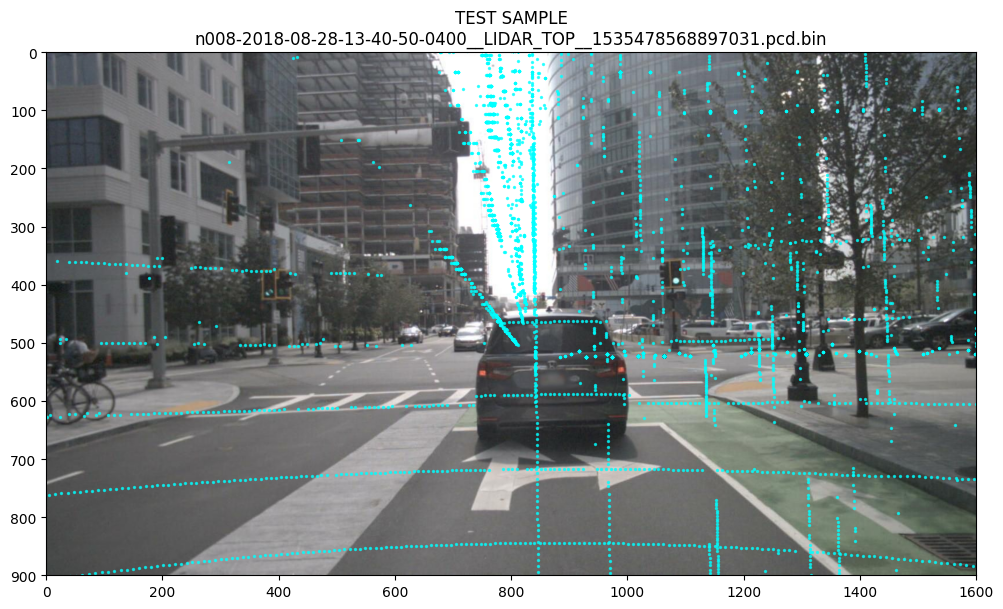

In [ ]:
from pathlib import Path
import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.geometry_utils import transform_matrix, view_points
from pyquaternion import Quaternion
from PIL import Image
import matplotlib.pyplot as plt

# ----------------------
# PATHS
# ----------------------
NUSCENES_ROOT = Path("~/Desktop/datasets/nuscenes_pseudo_test").expanduser()
NUSCENES_VERSION = "v1.0-pseudo-test"

LIDAR_FILE = "n008-2018-08-28-13-40-50-0400__LIDAR_TOP__1535478568897031.pcd.bin"
# LIDAR_FILE = "n008-2018-08-01-15-34-25-0400__LIDAR_TOP__1533152222947220.pcd.bin"
lidar_path = NUSCENES_ROOT / "samples" / "LIDAR_TOP" / LIDAR_FILE


# ----------------------
# LOAD LIDAR
# ----------------------
def load_bin_pts(path):
    arr = np.fromfile(str(path), dtype=np.float32)
    return arr.reshape(-1, 4)

pts = load_bin_pts(lidar_path)
pts_xyz = pts[:, :3]

# ----------------------
# LOAD NUSCENES TEST
# ----------------------
nusc = NuScenes(version=NUSCENES_VERSION, dataroot=str(NUSCENES_ROOT), verbose=False)

# Find sample_token
sample_token = None
for sd in nusc.sample_data:
    if sd["channel"] == "LIDAR_TOP" and sd["filename"].endswith(LIDAR_FILE):
        sample_token = sd["sample_token"]
        cam_sd_token = nusc.get("sample", sample_token)["data"]["CAM_FRONT"]
        break

if sample_token is None:
    raise RuntimeError("Could not match lidar file to sample_token.")

cam_sd = nusc.get("sample_data", cam_sd_token)
cam_fname = cam_sd["filename"]  # e.g., "samples/CAM_FRONT/..."
img_path = NUSCENES_ROOT / cam_fname


# ----------------------
# PROJECT LIDAR TO CAMERA
# ----------------------
calib_cam = nusc.get("calibrated_sensor", cam_sd["calibrated_sensor_token"])
ego_cam   = nusc.get("ego_pose", cam_sd["ego_pose_token"])

sample = nusc.get("sample", sample_token)
lid_sd_token = sample["data"]["LIDAR_TOP"]
lid_sd = nusc.get("sample_data", lid_sd_token)
calib_lid = nusc.get("calibrated_sensor", lid_sd["calibrated_sensor_token"])
ego_lid   = nusc.get("ego_pose", lid_sd["ego_pose_token"])

# homogeneous coords
pts_h = np.vstack((pts_xyz.T, np.ones((1, pts_xyz.shape[0]))))

# Lidar->ego_lid
T_lid_ego = transform_matrix(calib_lid['translation'], Quaternion(calib_lid['rotation']))
pts_ego = T_lid_ego @ pts_h

# ego_lid->global
T_ego_glob = transform_matrix(ego_lid['translation'], Quaternion(ego_lid['rotation']))
pts_glob = T_ego_glob @ pts_ego

# global->ego_cam
T_ego_cam = transform_matrix(ego_cam['translation'], Quaternion(ego_cam['rotation']))
T_glob_ego_cam = np.linalg.inv(T_ego_cam)
pts_ego_cam = T_glob_ego_cam @ pts_glob

# ego_cam->camera
T_cam_ego = transform_matrix(calib_cam['translation'], Quaternion(calib_cam['rotation']))
T_ego_cam2 = np.linalg.inv(T_cam_ego)
pts_cam = T_ego_cam2 @ pts_ego_cam
pts_cam3 = pts_cam[:3, :]

# project
intrinsic = np.array(calib_cam["camera_intrinsic"])
uv = view_points(pts_cam3, intrinsic, normalize=True)
u, v = uv[0, :], uv[1, :]
z = pts_cam3[2, :]


# ----------------------
# LOAD IMAGE
# ----------------------
img = np.array(Image.open(img_path))
H, W = img.shape[:2]

# ----------------------
# VISUALIZATION
# ----------------------
plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.scatter(u[z > 0], v[z > 0], s=2, c='cyan', alpha=0.7)
plt.title(f"TEST SAMPLE\n{LIDAR_FILE}")
plt.xlim(0, W)
plt.ylim(H, 0)
plt.show()


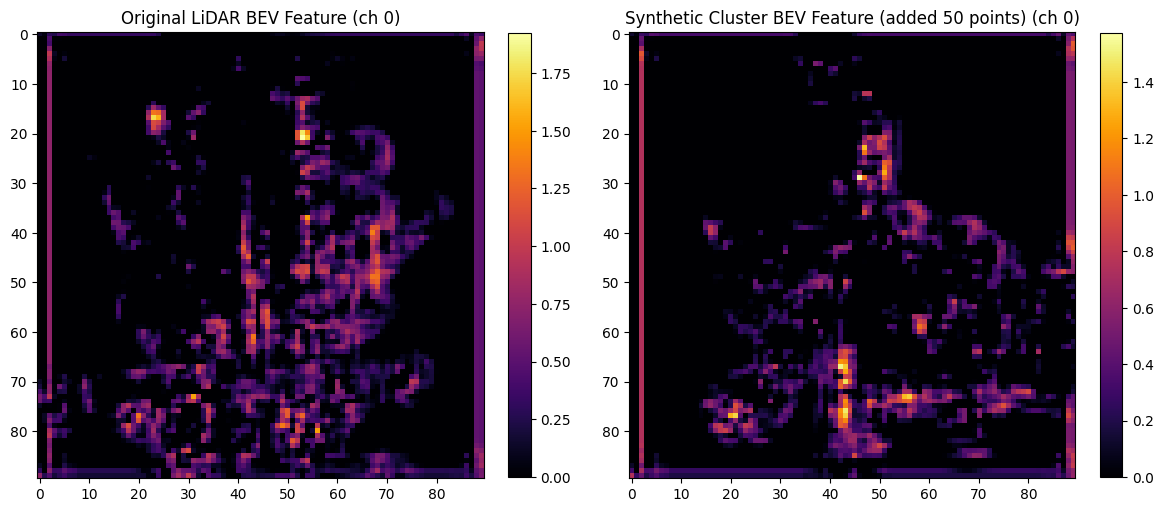

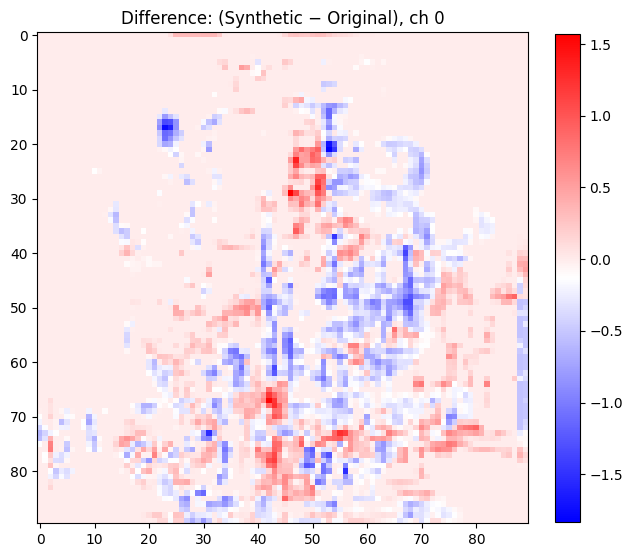

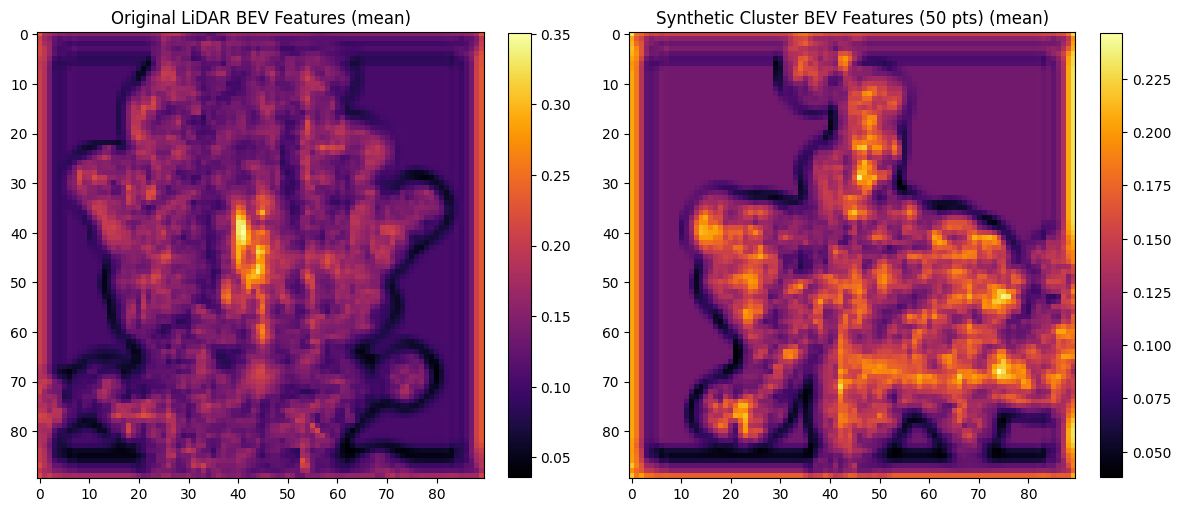

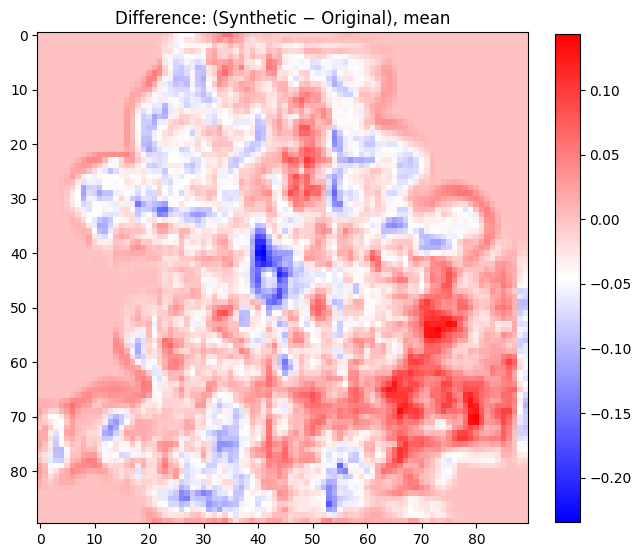

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load both features
# ============================
feat_orig  = torch.load("/home/draiman/Desktop/Datasets_nuscenes/testing/features_benign/lidar/5937faeeeb7d40b4903a441b0b95b204.pt",
                        map_location="cpu")["feat"].numpy()[0]   # [256, H, W]

                     

feat_synth = torch.load("/home/draiman/Desktop/Datasets_nuscenes/testing/features_lidar_drop/5937faeeeb7d40b4903a441b0b95b204.pt",
                        map_location="cpu")["feat"].numpy()[0]   # [256, H, W]

# pick channel 0 or any other (CenterPoint has 256 channels)
ch = 0
orig_ch  = feat_orig[ch]
synth_ch = feat_synth[ch]

# ============================
# Plot side-by-side
# ============================
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(orig_ch, cmap="inferno")
plt.title("Original LiDAR BEV Feature (ch 0)")
plt.colorbar(fraction=0.045)

plt.subplot(1, 2, 2)
plt.imshow(synth_ch, cmap="inferno")
plt.title("Synthetic Cluster BEV Feature (added 50 points) (ch 0)")
plt.colorbar(fraction=0.045)

plt.show()

plt.figure(figsize=(7,7))
plt.imshow(synth_ch - orig_ch, cmap="bwr")
plt.title("Difference: (Synthetic − Original), ch 0")
plt.colorbar(fraction=0.045)
plt.show()


# pick channel 0 or any other (CenterPoint has 256 channels)

# Compute mean across channels → shape [H, W]
orig_mean  = feat_orig.mean(axis=0)
synth_mean = feat_synth.mean(axis=0)

# ============================
# Plot side-by-side
# ============================
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(orig_mean, cmap="inferno")
plt.title("Original LiDAR BEV Features (mean)")
plt.colorbar(fraction=0.045)

plt.subplot(1, 2, 2)
plt.imshow(synth_mean, cmap="inferno")
plt.title("Synthetic Cluster BEV Features (50 pts) (mean)")
plt.colorbar(fraction=0.045)

plt.show()

plt.figure(figsize=(7,7))
plt.imshow(synth_mean - orig_mean, cmap="bwr")
plt.title("Difference: (Synthetic − Original), mean")
plt.colorbar(fraction=0.045)
plt.show()



In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Unpack features ---
# Example: feat_orig and feat_synth are loaded dicts from torch.load()
# Keys: 'voxel_feats', 'spatial', 'bev_c1', 'bev_c2'
# 1. Voxel features (shape: [N_voxels, 5])
voxel_feats_orig  = feat_orig['voxel_feats'].numpy()
voxel_feats_synth = feat_synth['voxel_feats'].numpy()

# 2. Spatial features (shape: [1, 256, 180, 180])
spatial_orig  = feat_orig['spatial'].numpy()[0]     # (256, 180, 180)
spatial_synth = feat_synth['spatial'].numpy()[0]

# 3. BEV_C1 features (shape: [1, 128, 180, 180])
bev_c1_orig  = feat_orig['bev_c1'].numpy()[0]       # (128, 180, 180)
bev_c1_synth = feat_synth['bev_c1'].numpy()[0]

# 4. BEV_C2 features (shape: [1, 256, 90, 90])
bev_c2_orig  = feat_orig['bev_c2'].numpy()[0]       # (256, 90, 90)
bev_c2_synth = feat_synth['bev_c2'].numpy()[0]

# --- Plot Voxel Feats (scatter, first 2 dims as x/y, color by intensity) ---
plt.figure(figsize=(17, 4))

plt.subplot(1, 2, 1)
plt.scatter(voxel_feats_orig[:, 0], voxel_feats_orig[:, 1], c=voxel_feats_orig[:, 4], cmap='inferno', s=1)
plt.title('Original voxel_feats (x vs y, colored by intensity)')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='intensity')

plt.subplot(1, 2, 2)
plt.scatter(voxel_feats_synth[:, 0], voxel_feats_synth[:, 1], c=voxel_feats_synth[:, 4], cmap='inferno', s=1)
plt.title('Synthetic voxel_feats (x vs y, colored by intensity) (2k pts added)')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='intensity')



plt.tight_layout()
plt.show()


# --- Helper: Plot mean across channels ---
def plot_mean_feats(ax, data, title, cmap="inferno"):
    ax.imshow(data.mean(axis=0), cmap=cmap)
    ax.set_title(title)
    ax.axis('off')

# --- 2. Plot Spatial features [mean across channels] ---
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
plot_mean_feats(axs[0], spatial_orig,  "Original: spatial (mean across ch.)")
plot_mean_feats(axs[1], spatial_synth, "Syn_point_drop: spatial (mean across ch.)")
plt.suptitle("Spatial Features")
plt.tight_layout()
plt.show()

# --- 3. Plot BEV_C1 features [mean across channels] ---
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
plot_mean_feats(axs[0], bev_c1_orig,  "Original: bev_c1 (mean across ch.)")
plot_mean_feats(axs[1], bev_c1_synth, "Syn_point_drop: bev_c1 (mean across ch.)")
plt.suptitle("BEV_C1 Features")
plt.tight_layout()
plt.show()

# --- 4. Plot BEV_C2 features [mean across channels] ---
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
plot_mean_feats(axs[0], bev_c2_orig,  "Original: bev_c2 (mean across ch.)")
plot_mean_feats(axs[1], bev_c2_synth, "Syn_point_drop: bev_c2 (mean across ch.)")
plt.suptitle("BEV_C2 Features")
plt.tight_layout()
plt.show()


# --- 5. Plot the difference (synthetic - original) for each feature and both synth variants ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# First row: diff for synth_2000pts - orig
diff_spatial_point_drop = spatial_synth.mean(axis=0) - spatial_orig.mean(axis=0)
diff_bev_c1_point_drop = bev_c1_synth.mean(axis=0)  - bev_c1_orig.mean(axis=0)
diff_bev_c2_point_drop  = bev_c2_synth.mean(axis=0)  - bev_c2_orig.mean(axis=0)

axs[0, 0].imshow(diff_spatial_point_drop, cmap="bwr")
axs[0, 0].set_title("Spatial: (Syn__point_drop - Orig), mean")
axs[0, 1].imshow(diff_bev_c1_point_drop, cmap="bwr")
axs[0, 1].set_title("BEV_C1: (Syn__point_drop - Orig), mean")
axs[0, 2].imshow(diff_bev_c2_point_drop, cmap="bwr")
axs[0, 2].set_title("BEV_C2: (Syn__point_drop - Orig), mean")

for i in range(2):
    for j in range(3):
        axs[i, j].axis('off')

plt.suptitle("Difference Maps: Synthetic Variants vs Original")
plt.tight_layout()
plt.show()


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

coming from nuscenes_dataset.ipynb

<h3 style="font-size: 20px; font-weight: 600; margin-top: 20px; margin-bottom: 10px;">
This part, we are using the mmdetection3D venv to run some tests. So we want to know how our FoV cropping is working. Are we cropping the right angle?  
TO answer this we are going to get a sample, apply a cluster pf lidar points on different directions (mostly on front cam FoV) a cluster of points to the right/left/front (far/near). Then project the lidar on front cam image and observe the difference in points projected (better project on white plain image and color the projcted points)
</h3>

<h4 style="font-size: 18px;" > Note: Here is am not projecting lidar--> cam --> lidar, i am only doing lidar--> cam  <h4>



In [8]:

import numpy as np
import torch


# Define BEVSpec
class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min; self.x_max = x_max; self.cell_x = cell_x
        self.y_min = y_min; self.y_max = y_max; self.cell_y = cell_y
    
    @property
    def H(self): return int(np.ceil((self.x_max - self.x_min) / self.cell_x))
    @property
    def W(self): return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

def lidar_to_bev(points, bev_spec):
    x, y, z, i = points.T

    mask = (x >= bev_spec.x_min) & (x < bev_spec.x_max) & \
           (y >= bev_spec.y_min) & (y < bev_spec.y_max)
    x, y, z, i = x[mask], y[mask], z[mask], i[mask]

    ix = ((x - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
    iy = ((y - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)

    H, W = bev_spec.H, bev_spec.W
    bev_occ   = np.zeros((H, W), dtype=np.float32)
    bev_height = np.zeros((H, W), dtype=np.float32)
    bev_int   = np.zeros((H, W), dtype=np.float32)
    bev_count = np.zeros((H, W), dtype=np.float32)

    for px, py, pz, pi in zip(ix, iy, z, i):
        bev_occ[px, py] = 1
        bev_height[px, py] = max(bev_height[px, py], pz)
        bev_int[px, py] += pi
        bev_count[px, py] += 1

    bev_mean_int = bev_int / (bev_count + 1e-6)

    bev = np.stack([bev_occ, bev_height, bev_mean_int], axis=0)
    return bev

# front half x_min=0.0,, to see full 360deg, use x_min=-50.0 
# bev_spec = BEVSpec(
#     x_min=0.0,  x_max=50.0, cell_x=0.4,
#     y_min=-25.0, y_max=25.0, cell_y=0.25
# )


In [9]:
from pathlib import Path
import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.geometry_utils import transform_matrix, view_points
from pyquaternion import Quaternion
from PIL import Image
import matplotlib.pyplot as plt

# ----------------------
# PATHS
# ----------------------
NUSCENES_ROOT = Path("~/Desktop/datasets/nuscenes").expanduser()
NUSCENES_VERSION = "v1.0-trainval"

LIDAR_FILE = "n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"
# 
# lidar_path = NUSCENES_ROOT / "samples" / "LIDAR_TOP" / LIDAR_FILE
lidar_path = lidar_bin

# ----------------------
# LOAD NUSCENES TEST
# ----------------------
nusc = NuScenes(version=NUSCENES_VERSION, dataroot=str(NUSCENES_ROOT), verbose=False)

# Find sample_token
sample_token = None
for sd in nusc.sample_data:
    if sd["channel"] == "LIDAR_TOP" and sd["filename"].endswith(LIDAR_FILE):
        sample_token = sd["sample_token"]
        cam_sd_token = nusc.get("sample", sample_token)["data"]["CAM_FRONT"]
        break

if sample_token is None:
    raise RuntimeError("Could not match lidar file to sample_token.")

cam_sd = nusc.get("sample_data", cam_sd_token)
cam_fname = cam_sd["filename"]  # e.g., "samples/CAM_FRONT/..."
img_path = NUSCENES_ROOT / cam_fname


(34720, 4)


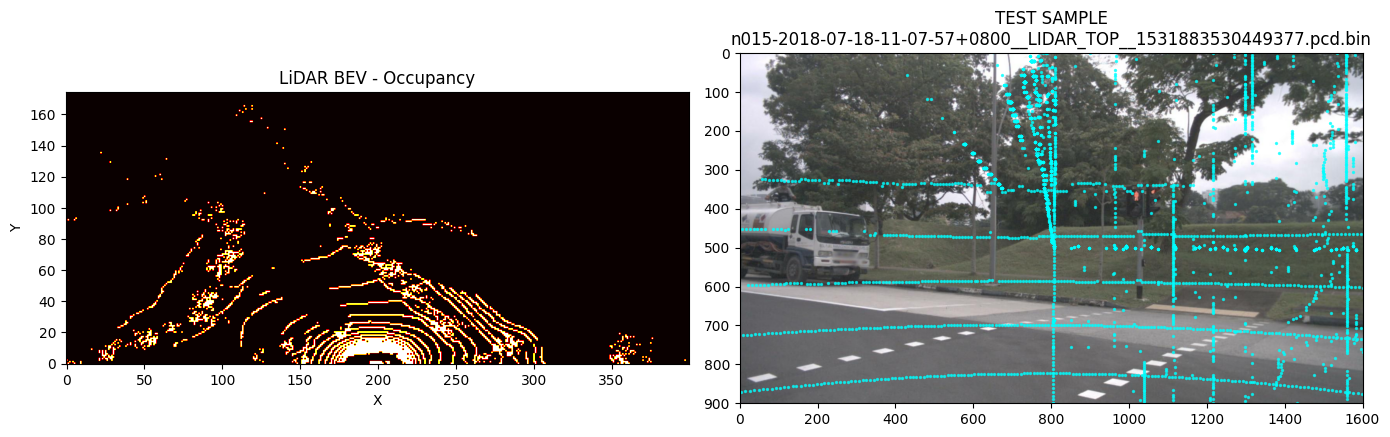

In [10]:


if __name__ == "__main__":
    
    # Load raw .pcd.bin
    lidar_bin = "/home/draiman/Desktop/datasets/nuscenes/samples/LIDAR_TOP/n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"

    points = np.fromfile(lidar_bin, dtype=np.float32).reshape(-1, 5)  # nuscenes = x,y,z,intensity,ring
    points = points[:, :4]  # keep x,y,z,i
    print(points.shape)
    points[:5]

    # Define BEVSpec
    bev_spec = BEVSpec(
        x_min=0.0,  x_max=70.0, cell_x=0.4,
        y_min=-50.0, y_max=50.0, cell_y=0.25
    )

    # Raw LiDAR → BEV
    bev = lidar_to_bev(points, bev_spec)
    bev.shape


    # ----------------------
    # LOAD LIDAR
    # ----------------------
    def load_bin_pts(path):
        arr = np.fromfile(str(path), dtype=np.float32)
        return arr.reshape(-1, 4)

    pts = load_bin_pts(lidar_path)
    pts_xyz = pts[:, :3]

    # ----------------------
    # PROJECT LIDAR TO CAMERA
    # ----------------------
    calib_cam = nusc.get("calibrated_sensor", cam_sd["calibrated_sensor_token"])
    ego_cam   = nusc.get("ego_pose", cam_sd["ego_pose_token"])

    sample = nusc.get("sample", sample_token)
    lid_sd_token = sample["data"]["LIDAR_TOP"]
    lid_sd = nusc.get("sample_data", lid_sd_token)
    calib_lid = nusc.get("calibrated_sensor", lid_sd["calibrated_sensor_token"])
    ego_lid   = nusc.get("ego_pose", lid_sd["ego_pose_token"])

    # homogeneous coords
    pts_h = np.vstack((pts_xyz.T, np.ones((1, pts_xyz.shape[0]))))

    # Lidar->ego_lid
    T_lid_ego = transform_matrix(calib_lid['translation'], Quaternion(calib_lid['rotation']))
    pts_ego = T_lid_ego @ pts_h

    # ego_lid->global
    T_ego_glob = transform_matrix(ego_lid['translation'], Quaternion(ego_lid['rotation']))
    pts_glob = T_ego_glob @ pts_ego

    # global->ego_cam
    T_ego_cam = transform_matrix(ego_cam['translation'], Quaternion(ego_cam['rotation']))
    T_glob_ego_cam = np.linalg.inv(T_ego_cam)
    pts_ego_cam = T_glob_ego_cam @ pts_glob

    # ego_cam->camera
    T_cam_ego = transform_matrix(calib_cam['translation'], Quaternion(calib_cam['rotation']))
    T_ego_cam2 = np.linalg.inv(T_cam_ego)
    pts_cam = T_ego_cam2 @ pts_ego_cam
    pts_cam3 = pts_cam[:3, :]

    # project
    intrinsic = np.array(calib_cam["camera_intrinsic"])
    uv = view_points(pts_cam3, intrinsic, normalize=True)
    u, v = uv[0, :], uv[1, :]
    z = pts_cam3[2, :]


    # ----------------------
    # LOAD IMAGE
    # ----------------------
    img = np.array(Image.open(img_path))
    H, W = img.shape[:2]

    # ----------------------
    # VISUALIZATION
    # ----------------------


    # # Visualize occupancy
    # import matplotlib.pyplot as plt

    # plt.figure(figsize=(7,7))
    # plt.imshow(bev[0], cmap="hot", origin="lower")
    # plt.title("LiDAR BEV - Occupancy")
    # plt.colorbar()
    # plt.show()

    # plt.figure(figsize=(12, 7))
    # plt.imshow(img)
    # plt.scatter(u[z > 0], v[z > 0], s=2, c='cyan', alpha=0.7)
    # plt.title(f"TEST SAMPLE\n{LIDAR_FILE}")
    # plt.xlim(0, W)
    # plt.ylim(H, 0)
    # plt.show()


    # Visualize occupancy + camera projection side-by-side
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# --------------------------------
# LEFT: LiDAR BEV Occupancy
# --------------------------------
axes[0].imshow(bev[0], cmap="hot", origin="lower")
axes[0].set_title("LiDAR BEV - Occupancy")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

# --------------------------------
# RIGHT: Camera image + projected LiDAR points
# --------------------------------
axes[1].imshow(img)
axes[1].scatter(u[z > 0], v[z > 0], s=2, c='cyan', alpha=0.7)
axes[1].set_title(f"TEST SAMPLE\n{LIDAR_FILE}")
axes[1].set_xlim(0, W)
axes[1].set_ylim(H, 0)

plt.tight_layout()
plt.show()



In [2]:
# from nuscenes.nuscenes import NuScenes
# from nuscenes.utils.data_classes import LidarPointCloud
# from nuscenes.utils.geometry_utils import view_points
# from nuscenes.utils.data_classes import Box
# from nuscenes.utils.data_classes import LidarPointCloud
# from nuscenes.utils.data_io import load_bin_file
# import numpy as np
# import os

# # 1) Load dataset
# dataroot = "/path/to/nuscenes"   # change this
# nusc = NuScenes(version='v1.0-trainval', dataroot=dataroot, verbose=True)

# sample = nusc.sample[0]  # pick some sample
# camera_channel = 'CAM_FRONT'

# # 2) Get camera & lidar sample_data records
# sd_cam = nusc.get('sample_data', sample['data'][camera_channel])
# sd_lid = nusc.get('sample_data', sample['data']['LIDAR_TOP'])

# # 3) Load point cloud in lidar frame
# lidar_path = os.path.join(dataroot, sd_lid['filename'])
# pc = LidarPointCloud.from_file(lidar_path)      # shape: (4, N)

# # 4) Get calibration + poses
# cs_lid = nusc.get('calibrated_sensor', sd_lid['calibrated_sensor_token'])
# cs_cam = nusc.get('calibrated_sensor', sd_cam['calibrated_sensor_token'])

# ep_lid = nusc.get('ego_pose', sd_lid['ego_pose_token'])
# ep_cam = nusc.get('ego_pose', sd_cam['ego_pose_token'])

# # 5) Transform LiDAR → ego (at lidar time) → global
# from pyquaternion import Quaternion

# pc.translate(cs_lid['translation'])
# pc.rotate(Quaternion(cs_lid['rotation']).rotation_matrix)
# pc.translate(ep_lid['translation'])
# pc.rotate(Quaternion(ep_lid['rotation']).rotation_matrix)

# # 6) Transform global → ego (at camera time) → camera frame
# pc.translate(-np.array(ep_cam['translation']))
# pc.rotate(Quaternion(ep_cam['rotation']).rotation_matrix.T)

# pc.translate(-np.array(cs_cam['translation']))
# pc.rotate(Quaternion(cs_cam['rotation']).rotation_matrix.T)

# # Now pc.points is in the camera coordinate frame
# points_cam = pc.points  # shape (4, N)
# depth = points_cam[2, :]  # z in camera frame

# # 7) Project to pixels
# K = np.array(cs_cam['camera_intrinsic'])  # 3x3
# pts_img = view_points(points_cam[:3, :], K, normalize=True)  # (3, N)
# u, v = pts_img[0, :], pts_img[1, :]

# # 8) FoV mask
# w, h = sd_cam['width'], sd_cam['height']
# in_front = depth > 0
# in_img = (u >= 0) & (u < w) & (v >= 0) & (v < h)
# fov_mask = in_front & in_img   # boolean, length N

# # E.g.:
# lidar_points_in_cam_fov = points_cam[:, fov_mask]


In [3]:
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud
from nuscenes.utils.geometry_utils import view_points
from nuscenes.utils.data_classes import Box
from nuscenes.utils.data_classes import LidarPointCloud
from nuscenes.utils.data_io import load_bin_file
import numpy as np
import os

# 1) Load dataset
dataroot = "/home/draiman/Desktop/datasets/nuscenes"   # change this
nusc = NuScenes(version='v1.0-trainval', dataroot=dataroot, verbose=True)

sample = nusc.sample[0]  # pick some sample
camera_channel = 'CAM_FRONT'

Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 27.905 seconds.
Reverse indexing ...
Done reverse indexing in 6.6 seconds.


In [4]:
# print(type(sample))
print(sample.keys())
print(sample['token'])

dict_keys(['token', 'timestamp', 'prev', 'next', 'scene_token', 'data', 'anns'])
e93e98b63d3b40209056d129dc53ceee


In [ ]:
sd_cam = nusc.get('sample_data', sample['data'][camera_channel])
sd_cam_ = sample['data'][camera_channel]
sd = sample['data']

print(type(sd_cam))
print(sd_cam.keys())
print(sd_cam['filename'])

print(type(sd_cam_))
print(sd_cam_)


print(type(sd))
print(sd)

<class 'dict'>
dict_keys(['token', 'sample_token', 'ego_pose_token', 'calibrated_sensor_token', 'timestamp', 'fileformat', 'is_key_frame', 'height', 'width', 'filename', 'prev', 'next', 'sensor_modality', 'channel'])
samples/CAM_FRONT/n015-2018-07-18-11-07-57+0800__CAM_FRONT__1531883530412470.jpg
<class 'str'>
020d7b4f858147558106c504f7f31bef
<class 'dict'>
{'RADAR_FRONT': 'bddd80ae33ec4e32b27fdb3c1160a30e', 'RADAR_FRONT_LEFT': '1a08aec0958e42ebb37d26612a2cfc57', 'RADAR_FRONT_RIGHT': '282fa8d7a3f34b68b56fb1e22e697668', 'RADAR_BACK_LEFT': '05fc4678025246f3adf8e9b8a0a0b13b', 'RADAR_BACK_RIGHT': '31b8099fb1c44c6381c3c71b335750bb', 'LIDAR_TOP': '3388933b59444c5db71fade0bbfef470', 'CAM_FRONT': '020d7b4f858147558106c504f7f31bef', 'CAM_FRONT_RIGHT': '16d39ff22a8545b0a4ee3236a0fe1c20', 'CAM_BACK_RIGHT': 'ec7096278e484c9ebe6894a2ad5682e9', 'CAM_BACK': 'aab35aeccbda42de82b2ff5c278a0d48', 'CAM_BACK_LEFT': '86e6806d626b4711a6d0f5015b090116', 'CAM_FRONT_LEFT': '24332e9c554a406f880430f17771b608'}


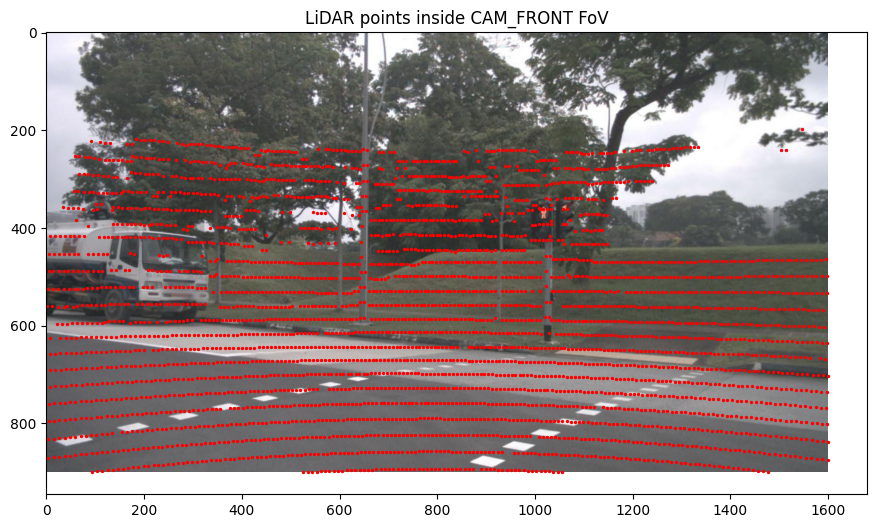

Total LiDAR points: 34720
Points inside CAM_FRONT FoV: 3364


In [6]:
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion
import numpy as np
import os
import matplotlib.pyplot as plt

# ===========================================================
# 1. Load dataset and choose your specific sample
# ===========================================================
dataroot = "/home/draiman/Desktop/datasets/nuscenes"
nusc = NuScenes(version='v1.0-trainval', dataroot=dataroot, verbose=False)

sample = nusc.sample[0]   # your chosen keyframe
cam = 'CAM_FRONT'


# ===========================================================
# 2. Get sample_data for camera and lidar
# ===========================================================
sd_cam  = nusc.get('sample_data', sample['data'][cam])
sd_lidar = nusc.get('sample_data', sample['data']['LIDAR_TOP'])

# Load calibration + poses
cs_cam = nusc.get('calibrated_sensor', sd_cam['calibrated_sensor_token'])
cs_lid = nusc.get('calibrated_sensor', sd_lidar['calibrated_sensor_token'])

ep_cam = nusc.get('ego_pose', sd_cam['ego_pose_token'])
ep_lid = nusc.get('ego_pose', sd_lidar['ego_pose_token'])


# ===========================================================
# 3. Load LiDAR point cloud in LIDAR_TOP frame
# ===========================================================
lidar_path = os.path.join(nusc.dataroot, sd_lidar['filename'])
pc = LidarPointCloud.from_file(lidar_path)   # shape = (4, N)


# ===========================================================
# 4. Transform LiDAR → CAM_FRONT coordinate system
# ===========================================================

# Step A: LIDAR_TOP → ego (at lidar time)
pc.rotate(Quaternion(cs_lid['rotation']).rotation_matrix)
pc.translate(cs_lid['translation'])

# ego (lidar time) → global
pc.rotate(Quaternion(ep_lid['rotation']).rotation_matrix)
pc.translate(ep_lid['translation'])

# global → ego (camera time)
pc.translate(-np.array(ep_cam['translation']))
pc.rotate(Quaternion(ep_cam['rotation']).rotation_matrix.T)

# ego (camera time) → camera frame
pc.translate(-np.array(cs_cam['translation']))
pc.rotate(Quaternion(cs_cam['rotation']).rotation_matrix.T)

points_cam = pc.points  # now in camera coordinates (4,N)


# ===========================================================
# 5. PROJECT TO IMAGE
# ===========================================================
K = np.array(cs_cam['camera_intrinsic'])
pts_img = view_points(points_cam[:3, :], K, normalize=True)
u, v = pts_img[0, :], pts_img[1, :]
depth = points_cam[2, :]


# ===========================================================
# 6. BUILD BOOLEAN FOV MASK
# ===========================================================
w, h = sd_cam['width'], sd_cam['height']

mask_in_front = depth > 0
mask_u = (u >= 0) & (u < w)
mask_v = (v >= 0) & (v < h)

fov_mask = mask_in_front & mask_u & mask_v   # FINAL ANSWER


# ===========================================================
# 7. OPTIONAL: visualize
# ===========================================================
img_path = os.path.join(nusc.dataroot, sd_cam['filename'])
img = plt.imread(img_path)

plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.scatter(u[fov_mask], v[fov_mask], s=2, c='red')
plt.title("LiDAR points inside CAM_FRONT FoV")
plt.show()

print(f"Total LiDAR points: {points_cam.shape[1]}")
print(f"Points inside CAM_FRONT FoV: {fov_mask.sum()}")


Total LiDAR points: 34720
Points inside CAM_FRONT FoV: 3364


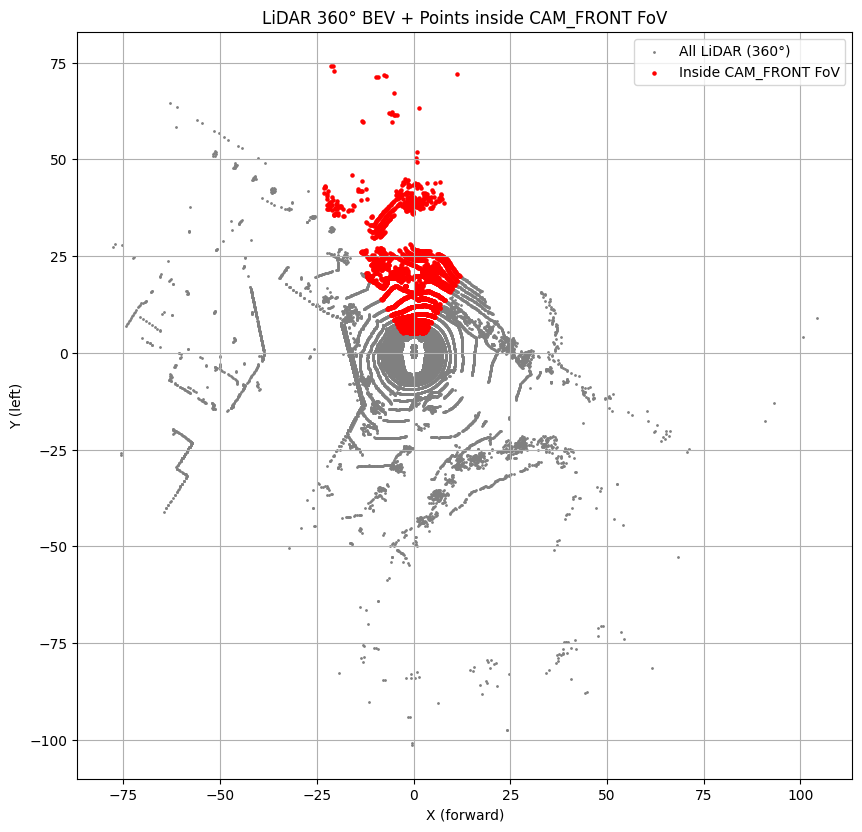

In [1]:
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion
import numpy as np
import os
import matplotlib.pyplot as plt

# ===========================================================
# 1. Load dataset and sample
# ===========================================================
dataroot = "/home/draiman/Desktop/datasets/nuscenes"
nusc = NuScenes(version='v1.0-trainval', dataroot=dataroot, verbose=False)

sample = nusc.sample[0]
cam = 'CAM_FRONT'

# camera + lidar sample_data
sd_cam = nusc.get('sample_data', sample['data'][cam])
sd_lidar = nusc.get('sample_data', sample['data']['LIDAR_TOP'])

# calibration + ego poses
cs_cam = nusc.get('calibrated_sensor', sd_cam['calibrated_sensor_token'])
cs_lid = nusc.get('calibrated_sensor', sd_lidar['calibrated_sensor_token'])
ep_cam = nusc.get('ego_pose', sd_cam['ego_pose_token'])
ep_lid = nusc.get('ego_pose', sd_lidar['ego_pose_token'])


# ===========================================================
# 2. Load original LiDAR points (keep a copy in lidar frame)
# ===========================================================
lidar_path = os.path.join(nusc.dataroot, sd_lidar['filename'])
pc = LidarPointCloud.from_file(lidar_path)     # shape (4,N)

# COPY of original points in LIDAR_TOP frame (before transforms)
points_lidar = pc.points.copy()                # used for BEV plotting later


# ===========================================================
# 3. Transform LiDAR → CAM_FRONT coordinates
# ===========================================================
# LIDAR_TOP → ego @ lidar time
pc.rotate(Quaternion(cs_lid['rotation']).rotation_matrix)
pc.translate(cs_lid['translation'])

# ego @ lidar time → global
pc.rotate(Quaternion(ep_lid['rotation']).rotation_matrix)
pc.translate(ep_lid['translation'])

# global → ego @ cam time
pc.translate(-np.array(ep_cam['translation']))
pc.rotate(Quaternion(ep_cam['rotation']).rotation_matrix.T)

# ego @ cam time → camera
pc.translate(-np.array(cs_cam['translation']))
pc.rotate(Quaternion(cs_cam['rotation']).rotation_matrix.T)

points_cam = pc.points   # in camera frame (4,N)


# ===========================================================
# 4. Build FOV mask
# ===========================================================
K = np.array(cs_cam['camera_intrinsic'])
pts_img = view_points(points_cam[:3, :], K, normalize=True)
u, v = pts_img[0], pts_img[1]
depth = points_cam[2]

w, h = sd_cam['width'], sd_cam['height']

fov_mask = (depth > 0) & (u >= 0) & (u < w) & (v >= 0) & (v < h)

print(f"Total LiDAR points: {points_lidar.shape[1]}")
print(f"Points inside CAM_FRONT FoV: {fov_mask.sum()}")


# ===========================================================
# 5. PLOT 360° BEV + Highlight CAM_FRONT FoV points
# ===========================================================
x = points_lidar[0, :]
y = points_lidar[1, :]

x_fov = x[fov_mask]
y_fov = y[fov_mask]

plt.figure(figsize=(10, 10))
plt.scatter(x, y, s=1, c='gray', label='All LiDAR (360°)')
plt.scatter(x_fov, y_fov, s=5, c='red', label='Inside CAM_FRONT FoV')

plt.gca().set_aspect('equal', 'box')
plt.title("LiDAR 360° BEV + Points inside CAM_FRONT FoV")
plt.xlabel("X (forward)")
plt.ylabel("Y (left)")
plt.legend()
plt.grid(True)
plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Same BEVSpec class you used
# -----------------------------
class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min; self.x_max = x_max; self.cell_x = cell_x
        self.y_min = y_min; self.y_max = y_max; self.cell_y = cell_y
    
    @property
    def H(self): return int(np.ceil((self.x_max - self.x_min) / self.cell_x))
    @property
    def W(self): return int(np.ceil((self.y_max - self.y_min) / self.cell_y))


bev_spec = BEVSpec(
    x_min=-50.0, x_max=50.0, cell_x=0.4,
    y_min=-25.0, y_max=25.0, cell_y=0.25
)


In [3]:
def lidar_to_bev(points, bev_spec):
    x, y, z, i = points.T

    mask = (x >= bev_spec.x_min) & (x < bev_spec.x_max) & \
           (y >= bev_spec.y_min) & (y < bev_spec.y_max)
    x, y, z, i = x[mask], y[mask], z[mask], i[mask]

    ix = ((x - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
    iy = ((y - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)

    H, W = bev_spec.H, bev_spec.W

    bev_occ   = np.zeros((H, W), dtype=np.float32)
    bev_height = np.zeros((H, W), dtype=np.float32)
    bev_int   = np.zeros((H, W), dtype=np.float32)
    bev_count = np.zeros((H, W), dtype=np.float32)

    for px, py, pz, pi in zip(ix, iy, z, i):
        bev_occ[px, py] = 1
        bev_height[px, py] = max(bev_height[px, py], pz)
        bev_int[px, py] += pi
        bev_count[px, py] += 1

    bev_mean_int = bev_int / (bev_count + 1e-6)
    bev = np.stack([bev_occ, bev_height, bev_mean_int], axis=0)
    return bev


In [4]:
# points_lidar is (4, N) from earlier code (x,y,z,i)
full_points = points_lidar.T                        # shape (N,4)
front_points = full_points[fov_mask]                # only CAM_FRONT-visible

bev_full = lidar_to_bev(full_points, bev_spec)
bev_front = lidar_to_bev(front_points, bev_spec)


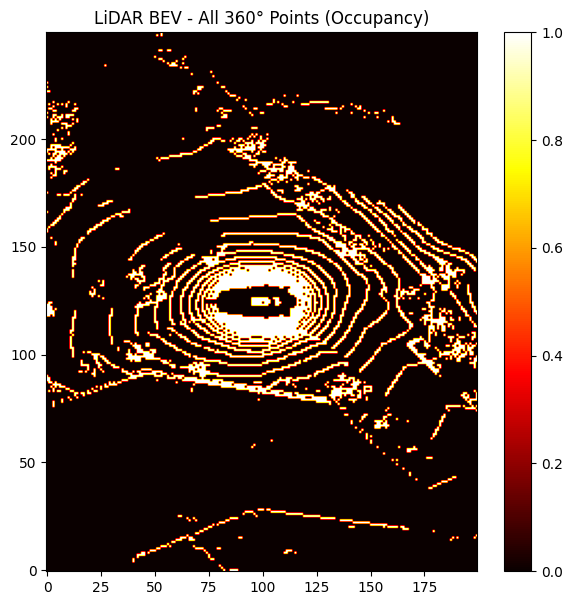

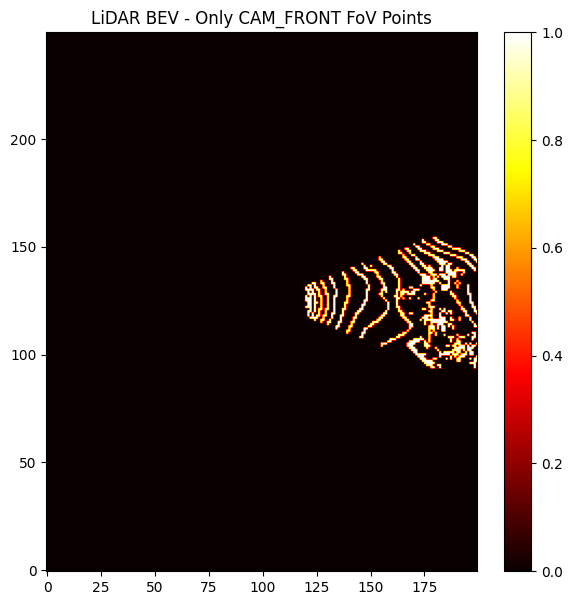

In [15]:
# ===== BEV 360° =====
plt.figure(figsize=(7,7))
plt.imshow(bev_full[0], cmap="hot", origin="lower")
plt.title("LiDAR BEV - All 360° Points (Occupancy)")
plt.colorbar()
plt.show()

# ===== BEV (CAM_FRONT-visible only) =====
plt.figure(figsize=(7,7))
plt.imshow(bev_front[0], cmap="hot", origin="lower")
plt.title("LiDAR BEV - Only CAM_FRONT FoV Points")
plt.colorbar()
plt.show()


In [5]:
front_points = full_points[fov_mask]   # shape (M, 4) = x,y,z,i

# Add a dummy ring channel (0)
rings = np.zeros((front_points.shape[0], 1), dtype=np.float32)

points_5d = np.hstack([front_points.astype(np.float32), rings])

# save_path = "/home/draiman/Desktop/masked_lidar.pcd.bin"
save_masked_sample_path = "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/dataset/masked_lidar.pcd.bin"

points_5d.tofile(save_masked_sample_path)

print("Saved masked LiDAR:", save_masked_sample_path)
print("Shape:", points_5d.shape)     # should be (M, 5)


Saved masked LiDAR: /home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/dataset/masked_lidar.pcd.bin
Shape: (3364, 5)


In [6]:
# Full unmasked LiDAR
rings_full = np.zeros((full_points.shape[0], 1), dtype=np.float32)
points_full_5d = np.hstack([full_points.astype(np.float32), rings_full])
save_full_sample_path = "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/dataset/full_lidar.pcd.bin"
points_5d.tofile(save_full_sample_path)


(3364, 4)


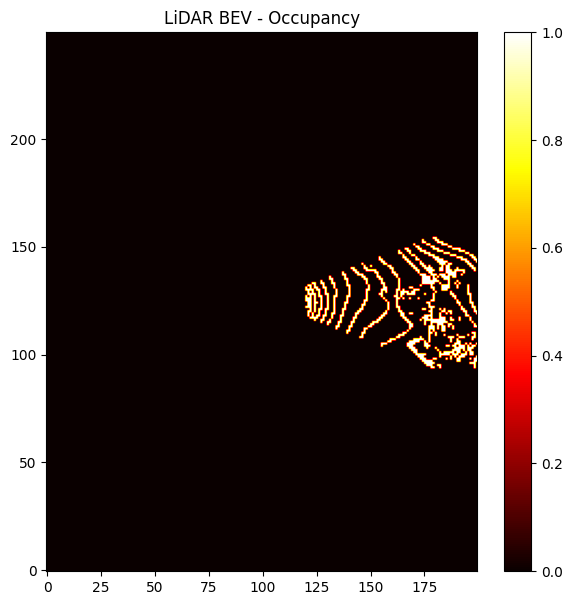

In [9]:
# Raw LiDAR → BEV

import torch
# Load raw .pcd.bin
import numpy as np

# lidar_bin = "/home/draiman/Desktop/datasets/nuscenes/samples/LIDAR_TOP/n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin"
lidar_bin = "/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/dataset/masked_lidar.pcd.bin"

points = np.fromfile(lidar_bin, dtype=np.float32).reshape(-1, 5)  # nuscenes = x,y,z,intensity,ring
points = points[:, :4]  # keep x,y,z,i
print(points.shape)
points[:5]

# Define BEVSpec
class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min; self.x_max = x_max; self.cell_x = cell_x
        self.y_min = y_min; self.y_max = y_max; self.cell_y = cell_y
    
    @property
    def H(self): return int(np.ceil((self.x_max - self.x_min) / self.cell_x))
    @property
    def W(self): return int(np.ceil((self.y_max - self.y_min) / self.cell_y))
# front half x_min=0.0,, to see full 360deg, use x_min=-50.0 
bev_spec = BEVSpec(
    x_min=-50.0,  x_max=50.0, cell_x=0.4,
    y_min=-25.0, y_max=25.0, cell_y=0.25
)
bev_spec.H, bev_spec.W

def lidar_to_bev(points, bev_spec):
    x, y, z, i = points.T

    mask = (x >= bev_spec.x_min) & (x < bev_spec.x_max) & \
           (y >= bev_spec.y_min) & (y < bev_spec.y_max)
    x, y, z, i = x[mask], y[mask], z[mask], i[mask]

    ix = ((x - bev_spec.x_min) / bev_spec.cell_x).astype(np.int32)
    iy = ((y - bev_spec.y_min) / bev_spec.cell_y).astype(np.int32)

    H, W = bev_spec.H, bev_spec.W
    bev_occ   = np.zeros((H, W), dtype=np.float32)
    bev_height = np.zeros((H, W), dtype=np.float32)
    bev_int   = np.zeros((H, W), dtype=np.float32)
    bev_count = np.zeros((H, W), dtype=np.float32)

    for px, py, pz, pi in zip(ix, iy, z, i):
        bev_occ[px, py] = 1
        bev_height[px, py] = max(bev_height[px, py], pz)
        bev_int[px, py] += pi
        bev_count[px, py] += 1

    bev_mean_int = bev_int / (bev_count + 1e-6)

    bev = np.stack([bev_occ, bev_height, bev_mean_int], axis=0)
    return bev

bev = lidar_to_bev(points, bev_spec)
bev.shape
# Visualize occupancy
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.imshow(bev[0], cmap="hot", origin="lower")
plt.title("LiDAR BEV - Occupancy")
plt.colorbar()
plt.show()


In [6]:
import torch
import os

def load_specific_cam_file(camera_dir, target_sample_token, fpn_level):
    # Compose the expected filename
    filename = f"{target_sample_token}_lvl{fpn_level}.pt"
    file_path = os.path.join(camera_dir, filename)
    return file_path

# --- Demo (replace with your real code as needed) ---
if __name__ == "__main__":
    fpn_level = 0
    camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT"
    # target_token = 'fd8420396768425eabec9bdddf7e64b6'
    target_sample_token = 'fd8420396768425eabec9bdddf7e64b6'
    
    # Build file name and path
    cam_path = load_specific_cam_file(camera_dir, target_sample_token, fpn_level)
    print("Chosen file path:", cam_path)

    # Load and process the file
    cam = torch.load(cam_path, map_location='cpu')
    cam_feat = cam['feat']
    print("img_shape ", cam['img_shape'])
    if cam_feat.ndim == 3:
        cam_feat = cam_feat.unsqueeze(0)
    print("Camera feature shape:", cam_feat.shape)



Chosen file path: /home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT/fd8420396768425eabec9bdddf7e64b6_lvl0.pt
img_shape  [(928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3)]
Camera feature shape: torch.Size([1, 256, 116, 200])


In [9]:
import json
import pprint

sample_data_json_path = "/home/draiman/Desktop/datasets/nuscenes/v1.0-trainval/sample_data.json"
target_sample_token = "fd8420396768425eabec9bdddf7e64b6"
desired_camera = "CAM_FRONT"  # Or any other camera name

with open(sample_data_json_path, 'r') as f:
    sample_data = json.load(f)

# Find all entries matching this sample_token
matching_entries = [entry for entry in sample_data if entry['sample_token'] == target_sample_token]

# Print all found entries
# print(f"\nAll entries for sample_token {target_sample_token}:")
# for entry in matching_entries:
#     pprint.pprint(entry)

# Now, find the entry for the desired camera
desired_entry = None
for entry in matching_entries:
    if desired_camera in entry['filename']:
        desired_entry = entry
        break

if desired_entry:
    print(f"\nThe {desired_camera} entry for sample_token {target_sample_token}:")
    pprint.pprint(desired_entry)
    print(f"\nIts token is: {desired_entry['token']}")
else:
    print(f"No {desired_camera} entry found for sample_token {target_sample_token}.")



The CAM_FRONT entry for sample_token fd8420396768425eabec9bdddf7e64b6:
{'calibrated_sensor_token': '774231675dc44f2792896d731c8709ff',
 'ego_pose_token': 'b8fba7d78cf547b996c431dec1f5ee26',
 'fileformat': 'jpg',
 'filename': 'samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201470412460.jpg',
 'height': 900,
 'is_key_frame': True,
 'next': '891a5802c274466c96e33955e8943d2d',
 'prev': '',
 'sample_token': 'fd8420396768425eabec9bdddf7e64b6',
 'timestamp': 1533201470412460,
 'token': 'b8fba7d78cf547b996c431dec1f5ee26',
 'width': 1600}

Its token is: b8fba7d78cf547b996c431dec1f5ee26


In [10]:
import pickle
import numpy as np

import pickle
from pyquaternion import Quaternion
import numpy as np
target_token = desired_entry['token'] # example 'b8fba7d78cf547b996c431dec1f5ee26'


with open("/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_val.pkl", "rb") as f:
    data = pickle.load(f)
infos = data['infos']

found = False
for idx, sample in enumerate(infos):
    cam_info = sample['cams']['CAM_FRONT']
    if cam_info['sample_data_token'] == target_token:
        print(f"Found at infos[{idx}]:")
        print(sample['cams']['CAM_FRONT'])
        found = True
        break

if not found:
    print(f"Token {target_token} not found in CAM_FRONT sample_data_token.")



cam_info = sample['cams']['CAM_FRONT']

KKK = np.array(cam_info['cam_intrinsic'])  # 3x3
RRR = Quaternion(cam_info['sensor2ego_rotation']).rotation_matrix
TTT = np.array(cam_info['sensor2ego_translation'])

print("Camera Intrinsic (K):\n", KKK)
print("Camera->ego rotation (RRR):\n", RRR)
print("Camera->ego translation (TTT):\n", TTT)


Found at infos[0]:
{'data_path': '/data/nuscenes/samples/CAM_FRONT/n015-2018-08-02-17-16-37+0800__CAM_FRONT__1533201470412460.jpg', 'type': 'CAM_FRONT', 'sample_data_token': 'b8fba7d78cf547b996c431dec1f5ee26', 'sensor2ego_translation': [1.70079118954, 0.0159456324149, 1.51095763913], 'sensor2ego_rotation': [0.4998015430569128, -0.5030316162024876, 0.4997798114386805, -0.49737083824542755], 'ego2global_translation': [249.90018228466124, 917.5514452794962, 0.0], 'ego2global_rotation': [0.9984397071954904, -0.008652973321832425, 0.002523596051210081, -0.05510815376190409], 'timestamp': 1533201470412460, 'sensor2lidar_rotation': array([[ 0.99996937,  0.0067556 , -0.0039516 ],
       [ 0.00382456,  0.01871645,  0.99981752],
       [ 0.00682833, -0.99980201,  0.01869004]]), 'sensor2lidar_translation': array([-0.01271581,  0.76880558, -0.31059456]), 'cam_intrinsic': array([[1.26641720e+03, 0.00000000e+00, 8.16267020e+02],
       [0.00000000e+00, 1.26641720e+03, 4.91507066e+02],
       [0.0000

In [11]:
import torch
import os

def load_specific_cam_file(camera_dir, target_sample_token, fpn_level):
    # Compose the expected filename
    filename = f"{target_sample_token}_lvl{fpn_level}.pt"
    file_path = os.path.join(camera_dir, filename)
    return file_path

# --- Demo (replace with your real code as needed) ---
if __name__ == "__main__":
    fpn_level = 0
    camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT"
    # target_token = 'fd8420396768425eabec9bdddf7e64b6'
    target_sample_token = 'fd8420396768425eabec9bdddf7e64b6'
    
    # Build file name and path
    cam_path = load_specific_cam_file(camera_dir, target_sample_token, fpn_level)
    print("Chosen file path:", cam_path)

    # Load and process the file
    cam = torch.load(cam_path, map_location='cpu')
    cam_feat = cam['feat']
    print("img_shape ", cam['img_shape'])
    if cam_feat.ndim == 3:
        cam_feat = cam_feat.unsqueeze(0)
    print("Camera feature shape:", cam_feat.shape)


Chosen file path: /home/draiman/Desktop/Datasets_nuscenes/validation/fpn/CAM_FRONT/fd8420396768425eabec9bdddf7e64b6_lvl0.pt
img_shape  [(928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3), (928, 1600, 3)]
Camera feature shape: torch.Size([1, 256, 116, 200])


In [12]:
# testing 



import torch
import os
import glob
import numpy as np

import pickle
from pyquaternion import Quaternion
import numpy as np


# --- Demo (remove this block if you have real P2) ---
# Dummy P2 to test the printouts:
if __name__ == "__main__":


    # ---- Step 2: Define BEV grid ----
    # Set BEV spatial coverage and cell size
    cell_x = 0.4    # meters per cell (longitudinal, X/forward)
    cell_y = 0.25   # meters per cell (lateral, Y/sideways)
    x_min, x_max = 0.0, 50.0      # forward: 0 to 50 meters
    y_min, y_max = -25.0, 25.0    # lateral: -25 to +25 meters

    H_bev = int(np.ceil((x_max - x_min) / cell_x))
    W_bev = int(np.ceil((y_max - y_min) / cell_y))
    print(f"BEV grid: {H_bev} x {W_bev} cells  (cell size: {cell_x}m x {cell_y}m)")




    # ---- Step 3: Compute image pixel centers for each P2 cell ----
    B, C, Hf, Wf = cam_feat.shape  # from your loaded P2
    stride_p2 = 4                  # Adjust if your FPN uses a different stride

    # Each P2 cell corresponds to image pixel:
    #   u = (j + 0.5) * stride_p2
    #   v = (i + 0.5) * stride_p2
    # j = torch.arange(Wf, dtype=torch.float32) + 0.5
    # i = torch.arange(Hf, dtype=torch.float32) + 0.5
    # u = j * stride_p2
    # v = i * stride_p2

    # # Create meshgrid of pixel centers (U: horizontal, V: vertical)
    # U, V = torch.meshgrid(u, v, indexing='xy')
    # U = U.t().contiguous()  # shape [Hf, Wf]
    # V = V.t().contiguous()  # shape [Hf, Wf]

    # print(f"U (image x pixel centers): shape {U.shape}, min={U.min().item():.1f}, max={U.max().item():.1f}")
    # print(f"V (image y pixel centers): shape {V.shape}, min={V.min().item():.1f}, max={V.max().item():.1f}")




    
    # Pick a center pixel index in feature space
    center_j = Wf // 2
    center_i = Hf // 2
    u_c = (center_j + 0.5) * stride_p2
    v_c = (center_i + 0.5) * stride_p2
    uv1 = np.array([u_c, v_c, 1.0])
    
    # Camera ray in pixel coords
    ray_cam = np.linalg.inv(KKK) @ uv1
    
    # Ray in ego coordinates
    ray_ego = RRR @ ray_cam
    
    # Camera center in ego frame
    cam_center_ego = TTT
    
    # Intersection with z=0 plane in ego frame
    cam_z = cam_center_ego[2]
    dir_z = ray_ego[2]
    if dir_z == 0:
        print("Warning, direction z=0")
    else:
        s = -cam_z / dir_z
        X_ground = cam_center_ego[0] + s * ray_ego[0]
        Y_ground = cam_center_ego[1] + s * ray_ego[1]
        print(f"Center pixel ground intersection: X={X_ground:.2f}  Y={Y_ground:.2f} (should be in front of vehicle)")


BEV grid: 125 x 200 cells  (cell size: 0.4m x 0.25m)
Center pixel ground intersection: X=-5.95  Y=-2.53 (should be in front of vehicle)


In [13]:
# new 
# ... after your current setup:
center_j = Wf // 2
center_i = Hf // 2
u_c = (center_j + 0.5) * stride_p2
v_c = (center_i + 0.5) * stride_p2
uv1 = np.array([u_c, v_c, 1.0])
ray_cam = np.linalg.inv(KKK) @ uv1

# TRY RRR.T INSTEAD OF RRR
ray_ego = RRR.T @ ray_cam
cam_center_ego = TTT
cam_z = cam_center_ego[2]
dir_z = ray_ego[2]
s = -cam_z / dir_z
X_ground = cam_center_ego[0] + s * ray_ego[0]
Y_ground = cam_center_ego[1] + s * ray_ego[1]
print(f"Center pixel ground intersection (RRR.T): X={X_ground:.2f}, Y={Y_ground:.2f}")


Center pixel ground intersection (RRR.T): X=2.62, Y=-4.50


In [14]:
# === NEW VERSION (drop-in replacement) ===
import torch
import numpy as np

# Expects already loaded:
# cam_feat: [B, C, Hf, Wf]
# KKK: 3x3 intrinsics (for the image size you used to extract features)
# RRR, TTT: nuScenes sensor2ego (camera->ego) rotation (3x3) and translation (3,)

# ---- BEV grid (unchanged) ----
cell_x = 0.4
cell_y = 0.25
x_min, x_max = 0.0, 50.0
y_min, y_max = -25.0, 25.0

B, C, Hf, Wf = cam_feat.shape
H_bev = int(np.ceil((x_max - x_min) / cell_x))
W_bev = int(np.ceil((y_max - y_min) / cell_y))
print(f"BEV grid: {H_bev} x {W_bev} cells  (cell size: {cell_x}m x {cell_y}m)")

bev_grid = torch.zeros((B, C, H_bev, W_bev), dtype=cam_feat.dtype)

# ---- FIX 1: correct FPN stride (P2 is 116x200 from 928x1600 -> stride 8) ----
stride_p2 = 8

# Pixel centers per feature location (V=row/y, U=col/x)
i = torch.arange(Hf, dtype=torch.float32) + 0.5
j = torch.arange(Wf, dtype=torch.float32) + 0.5
V, U = torch.meshgrid(i * stride_p2, j * stride_p2, indexing='ij')
print(f"U shape {U.shape}, V shape {V.shape}, U[min,max]=({U.min():.1f},{U.max():.1f}), V[min,max]=({V.min():.1f},{V.max():.1f})")

# ---- Intrinsics / Extrinsics ----
K = np.asarray(KKK, dtype=np.float64).copy()

# OPTIONAL: if K was for 1600x900 but your resized height is 928, scale fy and cy
# (Comment these two lines out if KKK already matches 928 height.)
scale_y = 928.0 / 900.0
K[1,1] *= scale_y;  K[1,2] *= scale_y

# nuScenes sensor2ego is camera->ego already
# R_cam2ego = np.asarray(RRR, dtype=np.float64)          # USE AS-IS (no transpose)
R_cam2ego = np.asarray(RRR, dtype=np.float64)
C_ego     = np.asarray(TTT, dtype=np.float64).reshape(3)  # camera center in ego

# ---- Backproject and intersect ground ----
K_inv = np.linalg.inv(K)
all_uv1 = np.stack([U.reshape(-1).numpy(), V.reshape(-1).numpy(), np.ones(Hf*Wf)], axis=0)  # [3, N]
rays_cam = K_inv @ all_uv1                 # [3, N] directions in camera
# rays_cam[1:3, :] *= -1   # now y_cam is up; DO NOT flip z
rays_cam[1, :] *= -1    
rays_ego = R_cam2ego @ rays_cam            # [3, N] directions in ego

cam_z = C_ego[2]
dir_z = rays_ego[2, :]
print(f"cam_z: {cam_z:.3f}, dir_z[min,max]: ({dir_z.min():.6f},{dir_z.max():.6f})")
print(f"% rays with dir_z < 0: {100.0 * (dir_z < 0).mean():.1f}%")

valid_down = dir_z < 0
print(f"Downward rays: {valid_down.sum()} / {len(dir_z)} ({100.0 * valid_down.mean():.1f}%)")


s = -cam_z / (dir_z + 1e-12)               # s>0 ⇒ forward intersection
# s= -cam_z / (rays_ego[2, :] + 1e-12)
X_ground = C_ego[0] + s * rays_ego[0, :]
Y_ground = C_ego[1] + s * rays_ego[1, :]

print("X_ground min/max:", float(X_ground.min()), float(X_ground.max()))
print("Y_ground min/max:", float(Y_ground.min()), float(Y_ground.max()))

# ---- Rasterize into BEV ----
ix = ((X_ground - x_min) / cell_x).astype(np.int64)
iy = ((Y_ground - y_min) / cell_y).astype(np.int64)
valid = (ix >= 0) & (ix < H_bev) & (iy >= 0) & (iy < W_bev) & (s > 0)

cam_feat_flat = cam_feat.reshape(B, C, -1)  # [B, C, Hf*Wf]
hits = 0
for b in range(B):
    for n in range(Hf * Wf):
        if valid[n]:
            bev_grid[b, :, ix[n], iy[n]] += cam_feat_flat[b, :, n]
            hits += 1
print(f"Valid splats: {hits} / {Hf*Wf}")

print(f"BEV grid shape: {bev_grid.shape}")
# === END NEW VERSION ===


BEV grid: 125 x 200 cells  (cell size: 0.4m x 0.25m)
U shape torch.Size([116, 200]), V shape torch.Size([116, 200]), U[min,max]=(4.0,1596.0), V[min,max]=(4.0,924.0)
cam_z: 1.511, dir_z[min,max]: (-0.391197,0.314344)
% rays with dir_z < 0: 55.2%
Downward rays: 12800 / 23200 (55.2%)
X_ground min/max: -1692.0850784955803 360.52581268525125
Y_ground min/max: -1099.9763032671262 484.8962278642961
Valid splats: 11786 / 23200
BEV grid shape: torch.Size([1, 256, 125, 200])


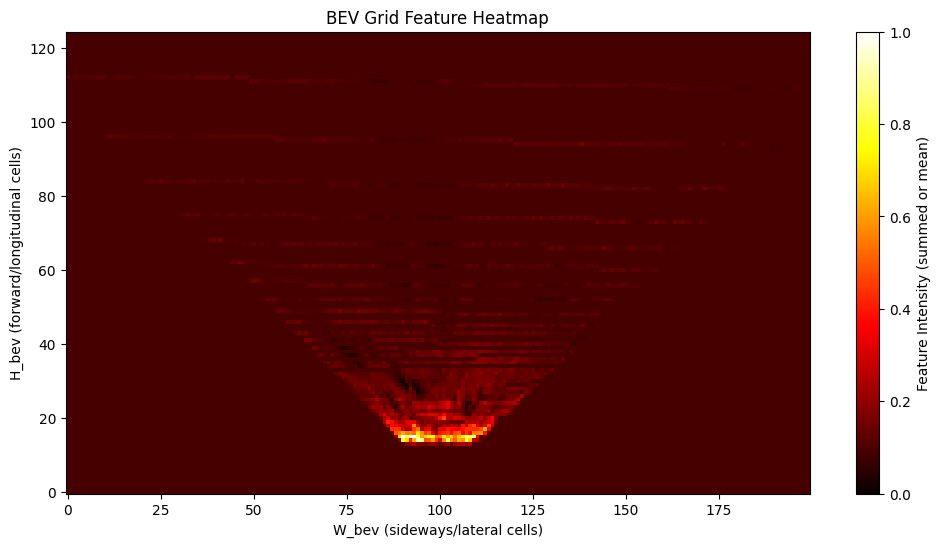

In [15]:
import matplotlib.pyplot as plt
import torch

# Suppose your BEV grid is named bev_grid, shape: [B, C, H_bev, W_bev]
# If you followed your previous code, it's likely [1, 256, 125, 200]

# Remove batch dimension (if present)
bev_img = bev_grid[0]  # shape: [C, H_bev, W_bev]

# Collapse feature channels: sum or mean
# bev_heat = bev_img.sum(dim=0)   # shape: [H_bev, W_bev]
# OR for mean:
bev_heat = bev_img.mean(dim=0)

# Optional: Normalize for display (0 to 1)
bev_heat = bev_heat.cpu().numpy()
bev_heat = (bev_heat - bev_heat.min()) / (bev_heat.max() - bev_heat.min() + 1e-8)

plt.figure(figsize=(12, 6))
plt.imshow(bev_heat, cmap='hot', aspect='auto', origin='lower')
plt.colorbar(label="Feature Intensity (summed or mean)")
plt.title("BEV Grid Feature Heatmap")
plt.xlabel("W_bev (sideways/lateral cells)")
plt.ylabel("H_bev (forward/longitudinal cells)")
plt.show()


In [16]:
from nuscenes.nuscenes import NuScenes

dataroot = "/home/draiman/Desktop/datasets/nuscenes"
nusc = NuScenes(version='v1.0-trainval', dataroot=dataroot, verbose=False)

sample = nusc.sample[0]       
cam_channel = 'CAM_FRONT'


In [17]:
# Get sample_data + calibrated sensors + ego poses

from pyquaternion import Quaternion

# Camera + LiDAR sample_data
sd_cam   = nusc.get('sample_data', sample['data'][cam_channel])
sd_lidar = nusc.get('sample_data', sample['data']['LIDAR_TOP'])

# Calibrations
cs_cam = nusc.get('calibrated_sensor', sd_cam['calibrated_sensor_token'])
cs_lid = nusc.get('calibrated_sensor', sd_lidar['calibrated_sensor_token'])

# Ego poses
ep_cam = nusc.get('ego_pose', sd_cam['ego_pose_token'])
ep_lid = nusc.get('ego_pose', sd_lidar['ego_pose_token'])


In [19]:
# Load LIDAR_TOP point cloud

import os
from nuscenes.utils.data_classes import LidarPointCloud

lidar_path = os.path.join(nusc.dataroot, sd_lidar['filename'])
pc = LidarPointCloud.from_file(lidar_path)   # shape (4, N)


In [20]:
# Transform LiDAR → camera coordinates

# LIDAR_TOP → ego (lidar time)
pc.rotate(Quaternion(cs_lid['rotation']).rotation_matrix)
pc.translate(cs_lid['translation'])

# ego (lidar time) → global
pc.rotate(Quaternion(ep_lid['rotation']).rotation_matrix)
pc.translate(ep_lid['translation'])

# global → ego (camera time)
pc.translate(-np.array(ep_cam['translation']))
pc.rotate(Quaternion(ep_cam['rotation']).rotation_matrix.T)

# ego → camera
pc.translate(-np.array(cs_cam['translation']))
pc.rotate(Quaternion(cs_cam['rotation']).rotation_matrix.T)

points_cam = pc.points  # now (4,N) in camera frame


In [21]:
# Project points to the image plane

from nuscenes.utils.geometry_utils import view_points
import numpy as np

K = np.array(cs_cam['camera_intrinsic'])

pts_img = view_points(points_cam[:3, :], K, normalize=True)
u = pts_img[0, :]
v = pts_img[1, :]
depth = points_cam[2, :]   # z in cam frame


In [22]:
# Filter points inside camera FoV

img_w, img_h = sd_cam['width'], sd_cam['height']

mask_in_front = depth > 0
mask_u = (u >= 0) & (u < img_w)
mask_v = (v >= 0) & (v < img_h)

fov_mask = mask_in_front & mask_u & mask_v


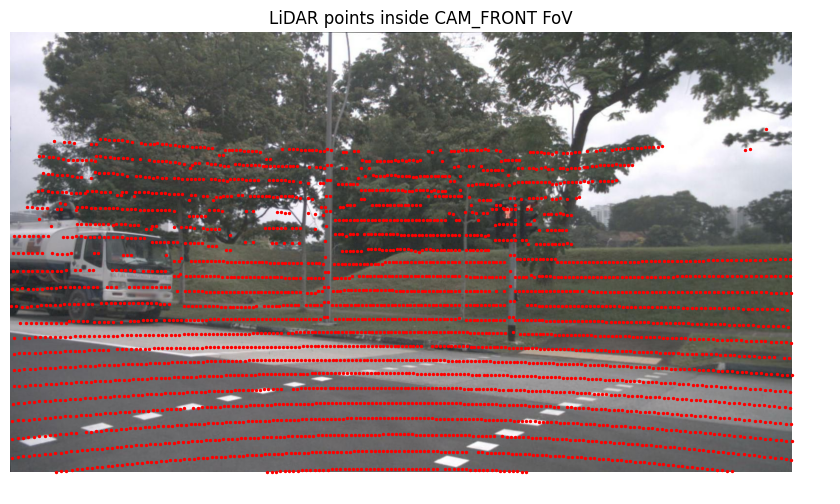

Total LiDAR points: 34720
Inside FoV: 3364


In [23]:
# Visualize LiDAR over the image

import matplotlib.pyplot as plt

img_path = os.path.join(nusc.dataroot, sd_cam['filename'])
img = plt.imread(img_path)

plt.figure(figsize=(12,6))
plt.imshow(img)
plt.scatter(u[fov_mask], v[fov_mask], s=2, c='red')
plt.title("LiDAR points inside CAM_FRONT FoV")
plt.axis('off')
plt.show()

print("Total LiDAR points:", points_cam.shape[1])
print("Inside FoV:", fov_mask.sum())


In [2]:
# Load nuScenes & pick sample[0]


from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
import numpy as np
import torch, os

dataroot = "/home/draiman/Desktop/datasets/nuscenes"
nusc = NuScenes(version="v1.0-trainval", dataroot=dataroot, verbose=False)

sample = nusc.sample[0]
cam_channel = "CAM_FRONT"
sd_cam = nusc.get('sample_data', sample['data'][cam_channel])


In [3]:
# Get intrinsics & extrinsics from devkit

cs_cam = nusc.get('calibrated_sensor', sd_cam['calibrated_sensor_token'])
ep_cam = nusc.get('ego_pose', sd_cam['ego_pose_token'])

K = np.array(cs_cam['camera_intrinsic'])

# camera → ego
R_cam2ego = Quaternion(cs_cam['rotation']).rotation_matrix
T_cam2ego = np.array(cs_cam['translation'])

# ego → global (not needed for BEV projection)
# ep_cam gives ego2global


In [5]:
# Load your FPN P2 features

fpn_level = 0
camera_dir = "/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT"
sample_token = sample['token']

pt_path = os.path.join(camera_dir, f"{sample_token}_lvl{fpn_level}.pt")

cam = torch.load(pt_path, map_location='cpu')
cam_feat = cam['feat']   # [1, C, Hf, Wf]

if cam_feat.ndim == 3:
    cam_feat = cam_feat.unsqueeze(0)

B, C, Hf, Wf = cam_feat.shape
print(cam_feat.shape)


torch.Size([1, 256, 116, 200])


In [7]:
# Compute pixel centers for feature map (using correct stride)
# Your image is 928×1600, P2 feature is 116×200 → stride = 8.


stride = 8
i = torch.arange(Hf, dtype=torch.float32) + 0.5
# print("Hf, Wf:", Hf, Wf)
# print("i:", i)
j = torch.arange(Wf, dtype=torch.float32) + 0.5

V, U = torch.meshgrid(i * stride, j * stride, indexing='ij')  # pixel coords
U = U.numpy()
V = V.numpy()


In [ ]:
# Backproject rays → camera → ego

K_inv = np.linalg.inv(K)

uv1 = np.stack([U.reshape(-1), V.reshape(-1), np.ones(Hf*Wf)], axis=0)
rays_cam = K_inv @ uv1     # (3, N)

# Adjust nuScenes convention: flip image y
rays_cam[1, :] *= -1

# camera → ego
rays_ego = R_cam2ego @ rays_cam

# camera center in ego
C_ego = T_cam2ego.reshape(3)


rays_ego[2, :] [-0.39110126 -0.39109618 -0.39109109 ...  0.33634768  0.33635277
  0.33635785]


In [9]:
# Intersect rays with ground plane z = 0
print("rays_ego[2, :]", rays_ego[2, :])
cam_z = C_ego[2]
dir_z = rays_ego[2, :]

s = -cam_z / (dir_z + 1e-12)
valid = s > 0

X = C_ego[0] + s * rays_ego[0, :]
Y = C_ego[1] + s * rays_ego[1, :]


rays_ego[2, :] [-0.39110126 -0.39109618 -0.39109109 ...  0.33634768  0.33635277
  0.33635785]


In [32]:
# Define BEV grid

cell_x = 0.4
cell_y = 0.25
x_min, x_max = 0, 50
y_min, y_max = -25, 25

H_bev = int(np.ceil((x_max - x_min) / cell_x))
W_bev = int(np.ceil((y_max - y_min) / cell_y))

bev = torch.zeros((C, H_bev, W_bev))


In [33]:
# Splat features into BEV
ix = ((X - x_min) / cell_x).astype(np.int64)
iy = ((Y - y_min) / cell_y).astype(np.int64)

inside = valid & (ix>=0)&(ix<H_bev)&(iy>=0)&(iy<W_bev)

feat_flat = cam_feat.reshape(C, -1)

for n in np.where(inside)[0]:
    bev[:, ix[n], iy[n]] += feat_flat[:, n]


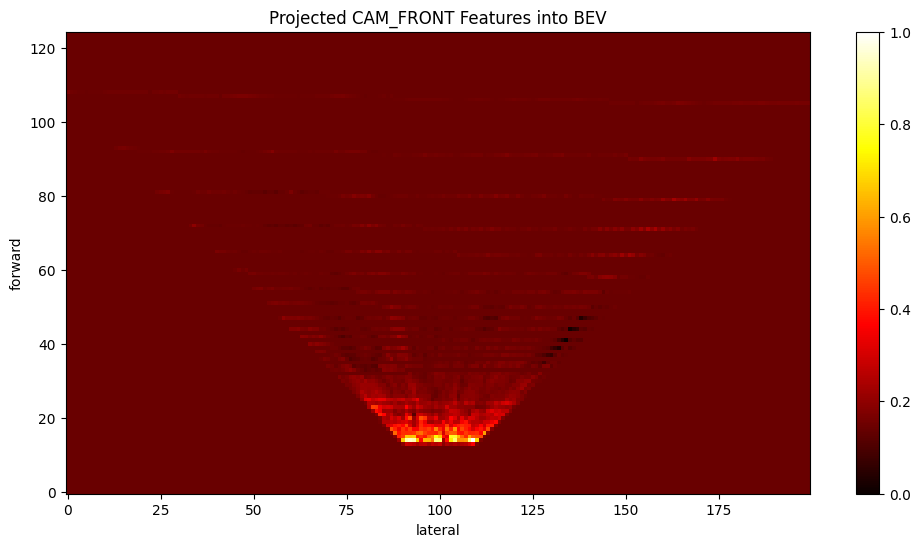

In [34]:
# Visualize BEV heatmap
import matplotlib.pyplot as plt

heat = bev.mean(dim=0).numpy()
heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)

plt.figure(figsize=(12,6))
plt.imshow(heat, cmap='hot', origin='lower', aspect='auto')
plt.colorbar()
plt.xlabel("lateral")
plt.ylabel("forward")
plt.title("Projected CAM_FRONT Features into BEV")
plt.show()


In [2]:
# Compare Old vs nuScenes Devkit Geometry
# ================================================================
# 1. Load nuScenes devkit values (from sample[0] CAM_FRONT)
# ================================================================
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
import numpy as np
import pickle, os

# Load dataset
dataroot = "/home/draiman/Desktop/datasets/nuscenes"
nusc = NuScenes(version="v1.0-trainval", dataroot=dataroot, verbose=False)

sample = nusc.sample[0]
cam = "CAM_FRONT"
sd_cam = nusc.get("sample_data", sample["data"][cam])

cs_cam = nusc.get("calibrated_sensor", sd_cam["calibrated_sensor_token"])
dev_K = np.array(cs_cam["camera_intrinsic"])
dev_R = Quaternion(cs_cam["rotation"]).rotation_matrix
dev_T = np.array(cs_cam["translation"])

# ================================================================
# 2. Load OLD version values from your pkl file (KKK, RRR, TTT)
# ================================================================
pkl_path = "/home/draiman/Desktop/datasets/nuscenes/nuscenes_infos_temporal_train_benign.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

# Find matching camera info for sample[0]
sample_token = sample["token"]
infos = data["infos"]

old_K = old_R = old_T = None

for entry in infos:
    cam_info = entry["cams"]["CAM_FRONT"]
    if cam_info["sample_data_token"] == sd_cam["token"]:
        old_K = np.array(cam_info["cam_intrinsic"])
        old_R = Quaternion(cam_info["sensor2ego_rotation"]).rotation_matrix
        old_T = np.array(cam_info["sensor2ego_translation"])
        break

# ================================================================
# 3. Print and compare all values
# ================================================================
print("=== DEVKIT Intrinsics K ===\n", dev_K)
print("=== OLD Intrinsics K ===\n", old_K)
print("K difference:\n", dev_K - old_K)

print("\n=== DEVKIT R_cam2ego ===\n", dev_R)
print("=== OLD R_cam2ego ===\n", old_R)
print("R difference:\n", dev_R - old_R)

print("\n=== DEVKIT T_cam2ego ===\n", dev_T)
print("=== OLD T_cam2ego ===\n", old_T)
print("T difference:\n", dev_T - old_T)

# Quick numerical checks
print("\nMax |K difference|:", np.abs(dev_K - old_K).max())
print("Max |R difference|:", np.abs(dev_R - old_R).max())
print("Max |T difference|:", np.abs(dev_T - old_T).max())





=== DEVKIT Intrinsics K ===
 [[1.26641720e+03 0.00000000e+00 8.16267020e+02]
 [0.00000000e+00 1.26641720e+03 4.91507066e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
=== OLD Intrinsics K ===
 [[1.26641720e+03 0.00000000e+00 8.16267020e+02]
 [0.00000000e+00 1.26641720e+03 4.91507066e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
K difference:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

=== DEVKIT R_cam2ego ===
 [[ 5.68477868e-03 -5.63666773e-03  9.99967955e-01]
 [-9.99983517e-01 -8.37115272e-04  5.68014846e-03]
 [ 8.05071338e-04 -9.99983763e-01 -5.64133364e-03]]
=== OLD R_cam2ego ===
 [[ 5.68477868e-03 -5.63666773e-03  9.99967955e-01]
 [-9.99983517e-01 -8.37115272e-04  5.68014846e-03]
 [ 8.05071338e-04 -9.99983763e-01 -5.64133364e-03]]
R difference:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

=== DEVKIT T_cam2ego ===
 [1.70079119 0.01594563 1.51095764]
=== OLD T_cam2ego ===
 [1.70079119 0.01594563 1.51095764]
T difference:
 [0. 0. 0.]

Max |K difference|: 0.0
Max |R difference|: 0.

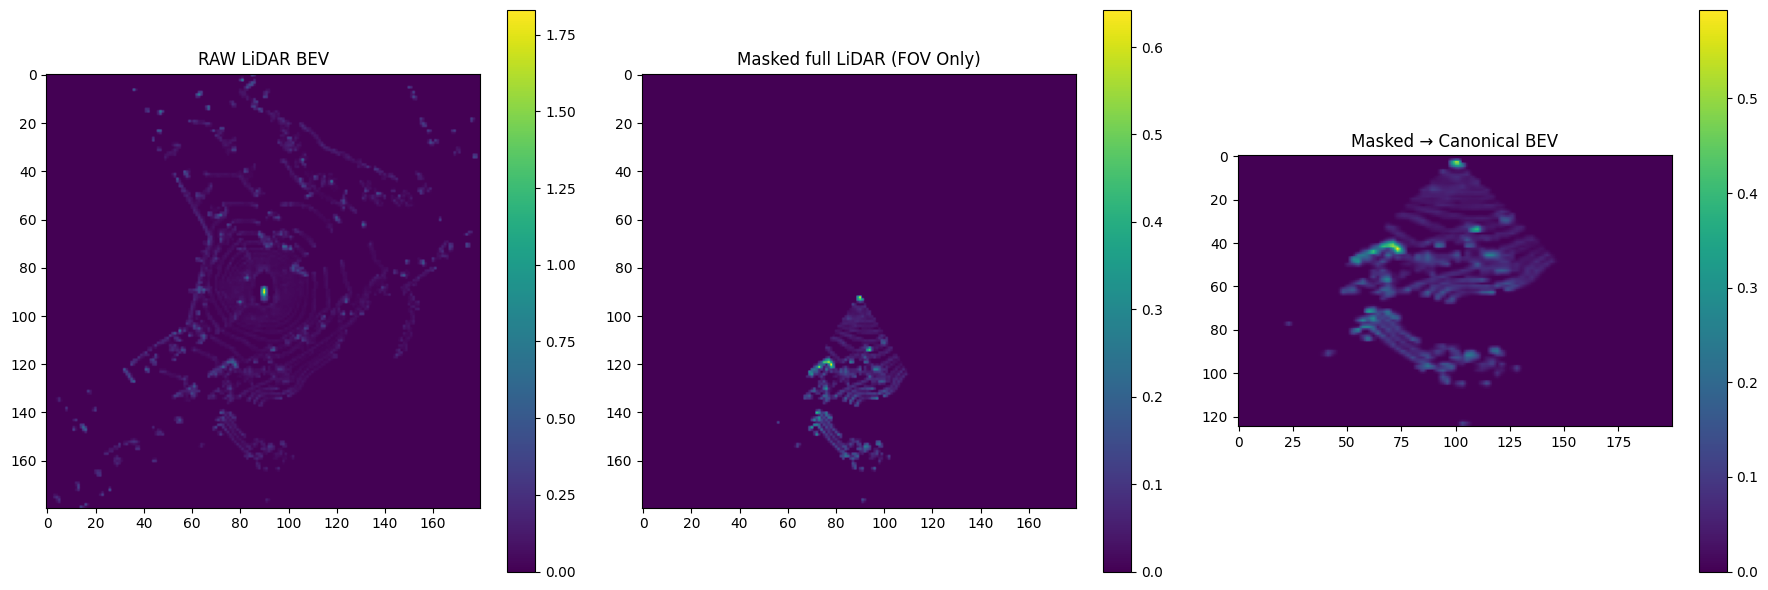

In [ ]:
import sys
sys.path.append("/home/draiman/Desktop/Nima/Lavis_blip2")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "e93e98b63d3b40209056d129dc53ceee"

lidar_file_full = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/benign_early_layers.pt"

cam_resnet_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/resnet/CAM_FRONT/{token}.pt"
cam_fpn_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/{token}_lvl0.pt"


# Load LiDAR BEV
# lidar_raw_full = torch.load(lidar_file)["bev_c2"].squeeze(0)   # [C, H, W]


# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
lidar2img = cam_raw["lidar2img"]
img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)




lidar_raw_full_o = torch.load(lidar_file_full)
lidar_raw_full = lidar_raw_full_o['spatial'].squeeze(0)
    
masked_full_lidar = crop_lidar_bev_to_camera_fov(
    lidar_raw_full,
    lidar2img,
    img_shape,
    # bev_resolution=(1.14, 1.14),
    bev_resolution = (0.57, 0.57),
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(0, 50, 0.4, -25, 25, 0.25)


# Lidar masked: [C, H_raw, W_raw] → add batch
lidar_masked_full_batch = masked_full_lidar.unsqueeze(0)

x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

lidar_bev_canonical = F.grid_sample(
    lidar_masked_full_batch, grid,
    mode='bilinear', padding_mode='zeros', align_corners=True
).squeeze(0)




masked_full_lidar_mean = masked_full_lidar.mean(0).numpy()


plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("RAW LiDAR BEV")
plt.imshow(lidar_raw_full.mean(0), cmap='viridis')
plt.colorbar()



plt.subplot(1, 3, 2)
plt.title("Masked full LiDAR (FOV Only)")
plt.imshow(masked_full_lidar.mean(0), cmap='viridis')
plt.colorbar()


plt.subplot(1, 3, 3)
plt.title("Masked → Canonical BEV")
plt.imshow(lidar_bev_canonical.mean(0), cmap='viridis')
plt.colorbar()

plt.tight_layout()
plt.show()



In [2]:
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion
import numpy as np

def get_lidar2img_from_nuscenes(nusc, sample_token, cam_channel="CAM_FRONT"):

    # ---------- 1. Load sample ----------
    sample = nusc.get("sample", sample_token)

    sd_lidar = nusc.get("sample_data", sample["data"]["LIDAR_TOP"])
    sd_cam   = nusc.get("sample_data", sample["data"][cam_channel])

    # ---------- 2. Load calibrations ----------
    cs_lidar = nusc.get("calibrated_sensor", sd_lidar["calibrated_sensor_token"])
    cs_cam   = nusc.get("calibrated_sensor", sd_cam["calibrated_sensor_token"])

    ep_lidar = nusc.get("ego_pose", sd_lidar["ego_pose_token"])
    ep_cam   = nusc.get("ego_pose", sd_cam["ego_pose_token"])

    # ---------- 3. Build transformation matrices ----------
    # lidar → ego (lidar time)
    lidar2ego = np.eye(4)
    lidar2ego[:3, :3] = Quaternion(cs_lidar["rotation"]).rotation_matrix
    lidar2ego[:3, 3]  = cs_lidar["translation"]

    # ego (lidar time) → global
    ego_lidar2global = np.eye(4)
    ego_lidar2global[:3, :3] = Quaternion(ep_lidar["rotation"]).rotation_matrix
    ego_lidar2global[:3, 3]  = ep_lidar["translation"]

    # global → ego (camera time)
    global2ego_cam = np.eye(4)
    global2ego_cam[:3, :3] = Quaternion(ep_cam["rotation"]).rotation_matrix.T
    global2ego_cam[:3, 3]  = -global2ego_cam[:3, :3].dot(ep_cam["translation"])

    # ego (camera time) → camera
    ego_cam2cam = np.eye(4)
    ego_cam2cam[:3, :3] = Quaternion(cs_cam["rotation"]).rotation_matrix.T
    ego_cam2cam[:3, 3]  = -ego_cam2cam[:3, :3].dot(cs_cam["translation"])

    # ---------- 4. Combine everything ----------
    lidar2cam = ego_cam2cam @ global2ego_cam @ ego_lidar2global @ lidar2ego

    # ---------- 5. Add intrinsics ----------
    K = np.array(cs_cam["camera_intrinsic"])       # 3×3
    lidar2img = K @ lidar2cam[:3, :]

    # ---------- 6. Get true image shape ----------
    img_shape = (sd_cam["height"], sd_cam["width"])   # (H, W)

    return lidar2img, img_shape



nusc = NuScenes(
    version='v1.0-trainval',
    dataroot="/home/draiman/Desktop/datasets/nuscenes",
    verbose=False
)

lidar2img_nusc, img_shape_nusc = get_lidar2img_from_nuscenes(nusc, token, "CAM_FRONT")


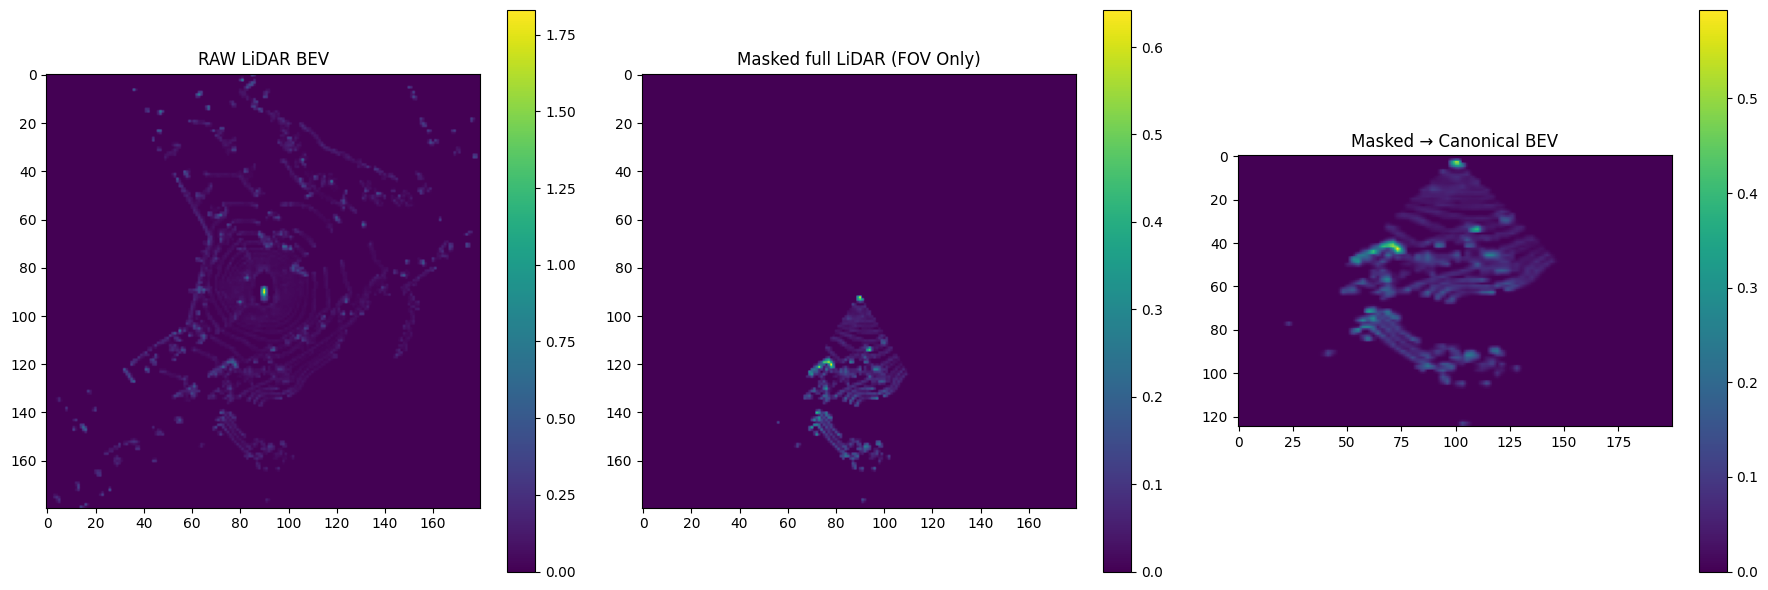

In [4]:
import sys
sys.path.append("/home/draiman/Desktop/Nima/Lavis_blip2")
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from  lavis.models.crop_lidar_bev import crop_lidar_bev_to_camera_fov

token = "e93e98b63d3b40209056d129dc53ceee"

lidar_file_full = f"/home/draiman/Desktop/Nima/Lavis_blip2/lavis/New_Model/dataset_processing/features_CP_layers/benign_early_layers.pt"

cam_resnet_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/resnet/CAM_FRONT/{token}.pt"
cam_fpn_file = f"/home/draiman/Desktop/Datasets_nuscenes/train/fpn/CAM_FRONT/{token}_lvl0.pt"


# Load LiDAR BEV
# lidar_raw_full = torch.load(lidar_file)["bev_c2"].squeeze(0)   # [C, H, W]


# Load camera ResNet (contains calibration!)
cam_raw = torch.load(cam_resnet_file, map_location="cpu")
# lidar2img = cam_raw["lidar2img"]
# img_shape = tuple(cam_raw["img_shape"][0])[:2]  # (H, W)

lidar2img = lidar2img_nusc
img_shape = img_shape_nusc


lidar_raw_full_o = torch.load(lidar_file_full)
lidar_raw_full_nusc = lidar_raw_full_o['spatial'].squeeze(0)
    
masked_full_lidar_nusc = crop_lidar_bev_to_camera_fov(
    lidar_raw_full_nusc,
    lidar2img,
    img_shape,
    # bev_resolution=(1.14, 1.14),
    bev_resolution = (0.57, 0.57),
    pc_range=[-51.2, -51.2, -5.0, 51.2, 51.2, 3.0]
)


class BEVSpec:
    def __init__(self, x_min, x_max, cell_x, y_min, y_max, cell_y):
        self.x_min = x_min
        self.x_max = x_max
        self.cell_x = cell_x
        self.y_min = y_min
        self.y_max = y_max
        self.cell_y = cell_y

    @property
    def H(self):
        return int(np.ceil((self.x_max - self.x_min) / self.cell_x))

    @property
    def W(self):
        return int(np.ceil((self.y_max - self.y_min) / self.cell_y))

bev_spec = BEVSpec(0, 50, 0.4, -25, 25, 0.25)


# Lidar masked: [C, H_raw, W_raw] → add batch
lidar_masked_full_batch = masked_full_lidar_nusc.unsqueeze(0)

x_min_l, y_min_l, _, x_max_l, y_max_l, _ = [-51.2, -51.2, -5, 51.2, 51.2, 3]

xs = bev_spec.x_min + (torch.arange(bev_spec.H) + 0.5) * bev_spec.cell_x
ys = bev_spec.y_min + (torch.arange(bev_spec.W) + 0.5) * bev_spec.cell_y
Xg, Yg = torch.meshgrid(xs, ys, indexing='ij')

grid_x = 2 * (Yg - y_min_l) / (y_max_l - y_min_l) - 1
grid_y = 2 * (Xg - x_min_l) / (x_max_l - x_min_l) - 1
grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)

lidar_bev_canonical_nusc = F.grid_sample(
    lidar_masked_full_batch, grid,
    mode='bilinear', padding_mode='zeros', align_corners=True
).squeeze(0)




masked_full_lidar_mean = masked_full_lidar_nusc.mean(0).numpy()


plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("RAW LiDAR BEV")
plt.imshow(lidar_raw_full_nusc.mean(0), cmap='viridis')
plt.colorbar()



plt.subplot(1, 3, 2)
plt.title("Masked full LiDAR (FOV Only)")
plt.imshow(masked_full_lidar_nusc.mean(0), cmap='viridis')
plt.colorbar()


plt.subplot(1, 3, 3)
plt.title("Masked → Canonical BEV")
plt.imshow(lidar_bev_canonical_nusc.mean(0), cmap='viridis')
plt.colorbar()

plt.tight_layout()
plt.show()



In [ ]:
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion
import numpy as np

def get_sensor_info_from_nuscenes(nusc, sample_token, cam_channel="CAM_FRONT"):
    """
    Returns calibration and pose info for both LIDAR_TOP and a camera,
    plus the lidar2img projection and image shape for camera masking/projection.
    """
    # ---------- 1. Load sample ----------
    sample = nusc.get("sample", sample_token)
    sd_lidar = nusc.get("sample_data", sample["data"]["LIDAR_TOP"])
    sd_cam   = nusc.get("sample_data", sample["data"][cam_channel])

    # ---------- 2. Load calibrations ----------
    cs_lidar = nusc.get("calibrated_sensor", sd_lidar["calibrated_sensor_token"])
    cs_cam   = nusc.get("calibrated_sensor", sd_cam["calibrated_sensor_token"])

    ep_lidar = nusc.get("ego_pose", sd_lidar["ego_pose_token"])
    ep_cam   = nusc.get("ego_pose", sd_cam["ego_pose_token"])

    # ---------- 3. Build transformation matrices ----------
    # lidar → ego (lidar time)
    lidar2ego = np.eye(4)
    lidar2ego[:3, :3] = Quaternion(cs_lidar["rotation"]).rotation_matrix
    lidar2ego[:3, 3]  = cs_lidar["translation"]

    # ego (lidar time) → global
    ego_lidar2global = np.eye(4)
    ego_lidar2global[:3, :3] = Quaternion(ep_lidar["rotation"]).rotation_matrix
    ego_lidar2global[:3, 3]  = ep_lidar["translation"]

    # global → ego (camera time)
    global2ego_cam = np.eye(4)
    global2ego_cam[:3, :3] = Quaternion(ep_cam["rotation"]).rotation_matrix.T
    global2ego_cam[:3, 3]  = -global2ego_cam[:3, :3].dot(ep_cam["translation"])

    # ego (camera time) → camera
    ego_cam2cam = np.eye(4)
    ego_cam2cam[:3, :3] = Quaternion(cs_cam["rotation"]).rotation_matrix.T
    ego_cam2cam[:3, 3]  = -ego_cam2cam[:3, :3].dot(cs_cam["translation"])

    # ---------- 4. Combine everything (LiDAR to Camera) ----------
    lidar2cam = ego_cam2cam @ global2ego_cam @ ego_lidar2global @ lidar2ego

    # ---------- 5. Camera intrinsics ----------
    K = np.array(cs_cam["camera_intrinsic"])       # 3×3
    lidar2img = K @ lidar2cam[:3, :]

    # ---------- 6. Get true image shape ----------
    img_shape = (sd_cam["height"], sd_cam["width"])   # (H, W)

    # ---------- 7. Also return all calibration info ----------
    calib_info = {
        "lidar2ego": lidar2ego,
        "ego_lidar2global": ego_lidar2global,
        "global2ego_cam": global2ego_cam,
        "ego_cam2cam": ego_cam2cam,
        "camera_intrinsic": K,
        "lidar2cam": lidar2cam,
        "lidar2img": lidar2img,
        "img_shape": img_shape,
        "cs_lidar": cs_lidar,
        "cs_cam": cs_cam,
        "ep_lidar": ep_lidar,
        "ep_cam": ep_cam,
        "sd_lidar": sd_lidar,
        "sd_cam": sd_cam,
        "sample": sample,
    }
    return calib_info

# Usage:
nusc = NuScenes(
    version='v1.0-trainval',
    dataroot="/home/draiman/Desktop/datasets/nuscenes",
    verbose=False
)

calib_info = get_sensor_info_from_nuscenes(nusc, token, "CAM_FRONT")
# Now you can access everything: calib_info["lidar2img"], calib_info["img_shape"], etc.
